# Predicting Wind Turbine Power Output: Regression Analysis
Lisa Wei\
0614940\
12/01/2026


AI disclaimer:
Ik heb LLM's gebruikt namelijk Gemini 3 vooral voor het genereren van code en debuggen, maar ook om concepten te begrijpen en het helpen bij het structureren van de opbouw van dit rapport. Ik zal vermelden wanneer er iets AI gegenereerd is. Alle teksten gegenereerd m.b.v. een AI staat tussen aanhalingstekens " " of krijgen een AI noot. Ik heb soms zelf aanpassingen gedaan in die teksten.


In [62]:
# numerical library:
import numpy as np

# data manipulation library:
import pandas as pd

# standard packages used to handle files:
import sys
import os 
import glob
import time

# scikit-learn machine learning library:
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

# plotting:
import matplotlib.pyplot as plt
import seaborn as sns

# ignore LightGBM yapping
import warnings

# tell matplotlib that we plot in a notebook:
%matplotlib inline

Sinds mijn intermediate report ben ik opnieuw begonnen, want eigenlijk begreep ik niets van wat ik deed, maar sommige dingen heb ik natuurlijk wel onthouden dat bijvoorbeeld de sinus en cosinus omzetting van de maanden en uren een betere score gaf. Al mijn Kaggle submissions van meer dan een maand geleden zijn dus niet van toepassing in dit verslag.

"Dit rapport presenteert een data-gedreven aanpak voor het voorspellen van de energieopbrengst van windturbines. Na een uitgebreide fase van feature engineering en hyperparameter-optimalisatie middels Optuna, zijn verschillende modellen vergeleken op hun voorspelkracht en generalisatievermogen.

Hoewel individuele modellen zoals XGBoost zeer competitieve resultaten lieten zien (9.80 kW), bleek een gewogen ensemble-benadering (het 'Triple Threat' model) de meest effectieve oplossing. Door de voorspellingen van Random Forest, LightGBM en XGBoost strategisch te combineren, werd een finale Mean Absolute Error (MAE) van 9.69 kW behaald op de Kaggle-testset. Dit resultaat onderstreept de meerwaarde van model-averaging bij het modelleren van turbulente atmosferische data en vormt de basis voor een uiterst nauwkeurige voorspellings-pipeline voor windenergie."

Noot: Deze sectie is geschreven met ondersteuning van AI.

## Problem and data analysis

In dit geval hebben we een supervised regressieprobleem. Het is supervised omdat we een gelabelde dataset krijgen, dus voor elke feature (wind speed, temperatuur...) hebben we een target value (active_power). Het is een regressieprobleem omdat onze target value (active_power) een continue waarde is, en dus geen discrete klasse.


AI gegenereerde hypothese:
"Ik verwacht een niet-lineaire relatie tussen de windsnelheid en het geproduceerde vermogen. Hoewel Lineaire Regressie zal dienen als baseline, is mijn hypothese dat Gradient Boosted Trees (zoals XGBoost of LightGBM) beter zullen presteren. Dit komt door hun vermogen om complexe patronen zoals de 'cut-in' (de snelheid waarbij de turbine begint te draaien) en de 'rated power' plateaus (de maximale capaciteit) te modelleren zonder dat hiervoor handmatige feature-transformaties nodig zijn."

"Voor dit project heb ik gefocust op de Mean Absolute Error (MAE), aangezien dit de officiële metriek van de Kaggle-competitie is. De keuze voor MAE is logisch binnen de context van windenergievoorspelling, omdat het een lineaire score geeft die direct vertaalbaar is naar geproduceerde kilowatturen (kW)."

In [2]:
data_folder = "./"

In [3]:
train_data = pd.read_csv(data_folder + "training_data.csv")
test_data = pd.read_csv(data_folder + "test_data.csv")

In [4]:
train_data.head()

,active_power,timestamp,pitch_angle,reactive_power,nacelle_angle,nacelle_temp,wind_speed1,wind_speed2,wind_speed_avg,wind_angle,...,outdoor_temp,rotor_angular_velocity,rotor_bearing_temp,weather_temp,pressure,humidity,weather_wind_speed,weather_wind_angle,rain_1h,snow_1h
0,801.22998,2013-01-01 00:00:00,-1.0,67.559998,286.00000,20.129999,7.52,7.76,7.64,286.19000,...,5.44,16.950001,26.049999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
1,943.16998,2013-01-01 00:10:00,-1.0,70.260002,286.00000,21.420000,8.18,8.45,8.31,288.32999,...,5.74,17.139999,26.100000,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
2,998.48999,2013-01-01 00:20:00,-1.0,75.330002,286.00000,22.049999,8.29,8.66,8.47,293.04001,...,6.09,17.150000,26.219999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
3,837.96002,2013-01-01 00:30:00,-1.0,82.739998,286.00000,22.299999,7.89,8.24,8.06,294.01999,...,6.35,16.910000,26.309999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0
4,871.57001,2013-01-01 00:40:00,-1.0,82.349998,294.17999,22.600000,7.86,8.20,8.03,299.22000,...,6.51,16.920000,26.389999,5.39,1011.0,75.0,5.66,180.0,0.0,0.0


Als we kijken naar de data, valt het op dat de features verschillende scales hebben. Dus het zou handig zijn om onze data te normaliseren. Hoewel dit niet nodig is voor tree-based modellen (Random forest, XGBoost), zou het wel goed zijn voor mijn lineaire regressiemodel en (mogelijk toekomstige) neural networks.

## Preprocessing en feature extraction

Voordat ik mijn data ga schalen, moet ik mijn timestamp omzetten naar bruikbare getallen omdat timestamp een object geeft en ik die getallen nodig heb voor de scaler (en visualisaties). Maar als we het uur (0 t.e.m. 23) schalen zou 0 bijvoorbeeld ver liggen van 23 voor het model. 

AI gegenereerde oplossing: Cyclical Encoding (Sinus/Cosinus) Om de cirkelvormige natuur van tijd te vangen, zetten we het uur om in twee nieuwe kolommen: een sinus en een cosinus. Hierdoor "begrijpt" het model dat 23:50 en 00:00 naast elkaar liggen. Dit doen we ook voor de maanden.

In [6]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Omzetten naar datetime
train_data['timestamp'] = pd.to_datetime(train_data['timestamp'])

# Features extraheren
train_data['hour'] = train_data['timestamp'].dt.hour
train_data['month'] = train_data['timestamp'].dt.month

# Cyclische transformatie voor het UUR (24 uur per dag)
train_data['hour_sin'] = np.sin(2 * np.pi * train_data['hour'] / 24)
train_data['hour_cos'] = np.cos(2 * np.pi * train_data['hour'] / 24)

# Cyclische transformatie voor de MAAND (12 maanden per jaar)
# We trekken 1 af van month zodat het 0-11 wordt voor de berekening
train_data['month_sin'] = np.sin(2 * np.pi * (train_data['month']-1) / 12)
train_data['month_cos'] = np.cos(2 * np.pi * (train_data['month']-1) / 12)

# NU pas de originelen verwijderen
# We houden de sinus/cosinus kolommen over, die bevatten alle info!
cols_to_drop = ['timestamp', 'hour', 'month']
train_data = train_data.drop(columns=cols_to_drop)

print("Klaar! De features zijn nu cyclisch en de originelen zijn verwijderd.")

Klaar! De features zijn nu cyclisch en de originelen zijn verwijderd.



"Ik heb ervoor gekozen om de variabelen hour en month eerst als tussenstap te creëren. Vervolgens zijn deze getransformeerd naar sinus- en cosinus-paren. Pas nadat de cyclische informatie volledig was vastgelegd in deze nieuwe kolommen, zijn de originele kolommen verwijderd. Dit zorgt voor een dataset die enkel numerieke, wiskundig logische features bevat voor de regressie-modellen."

**Verantwoording Feature Selectie**: Temporele Variabelen "Ik heb ervoor gekozen om specifiek het uur en de maand uit de timestamp te extraheren. Het uur is relevant vanwege het diurnale karakter van wind en temperatuur (dag/nacht verschillen), terwijl de maand de seizoensgebonden variaties in windsterkte en luchtdichtheid vangt. Andere tijdsindicatoren, zoals de dag van de maand, zijn weggelaten om te voorkomen dat het model patronen leert die berusten op toeval (noise) in plaats van fysieke wetmatigheden."

Dit heb ik ook nog specifiek gevraagd voor meer duidelijkheid:
**Waarom gebruiken we het jaar of de dag van de maand niet?** 

"Het Jaar: Als je het jaartal (bijv. 2010, 2011) als getal meegeeft, kan het model denken dat de opbrengst elk jaar lineair stijgt of daalt. Maar we willen juist dat het model patronen leert die altijd gelden. (Tenzij je wilt kijken naar slijtage van de turbine over de jaren heen, maar voor een korte voorspelling is dit vaak ruis).

Dag van de maand (1-31): De wind weet niet of het de 1e of de 15e van de maand is. Er is geen fysieke reden waarom de 12e van de maand anders zou zijn dan de 13e. Dit zou alleen maar voor "overfitting" zorgen."

Noot: De natuurkundige onderbouwing met betrekking tot de luchtdichtheid is geformuleerd met **ondersteuning van een AI** om de wetenschappelijke nauwkeurigheid te waarborgen.


In [7]:
train_data.head()

,active_power,pitch_angle,reactive_power,nacelle_angle,nacelle_temp,wind_speed1,wind_speed2,wind_speed_avg,wind_angle,vane_angle,...,pressure,humidity,weather_wind_speed,weather_wind_angle,rain_1h,snow_1h,hour_sin,hour_cos,month_sin,month_cos
0,801.22998,-1.0,67.559998,286.00000,20.129999,7.52,7.76,7.64,286.19000,0.16,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
1,943.16998,-1.0,70.260002,286.00000,21.420000,8.18,8.45,8.31,288.32999,2.33,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
2,998.48999,-1.0,75.330002,286.00000,22.049999,8.29,8.66,8.47,293.04001,7.01,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
3,837.96002,-1.0,82.739998,286.00000,22.299999,7.89,8.24,8.06,294.01999,8.05,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0
4,871.57001,-1.0,82.349998,294.17999,22.600000,7.86,8.20,8.03,299.22000,4.40,...,1011.0,75.0,5.66,180.0,0.0,0.0,0.0,1.0,0.0,1.0


Omdat ik mijn visualisaties van de data niet kon laten zien voordat timestamp weg was, zal ik ze nu laten zien.

## Extra visualisaties

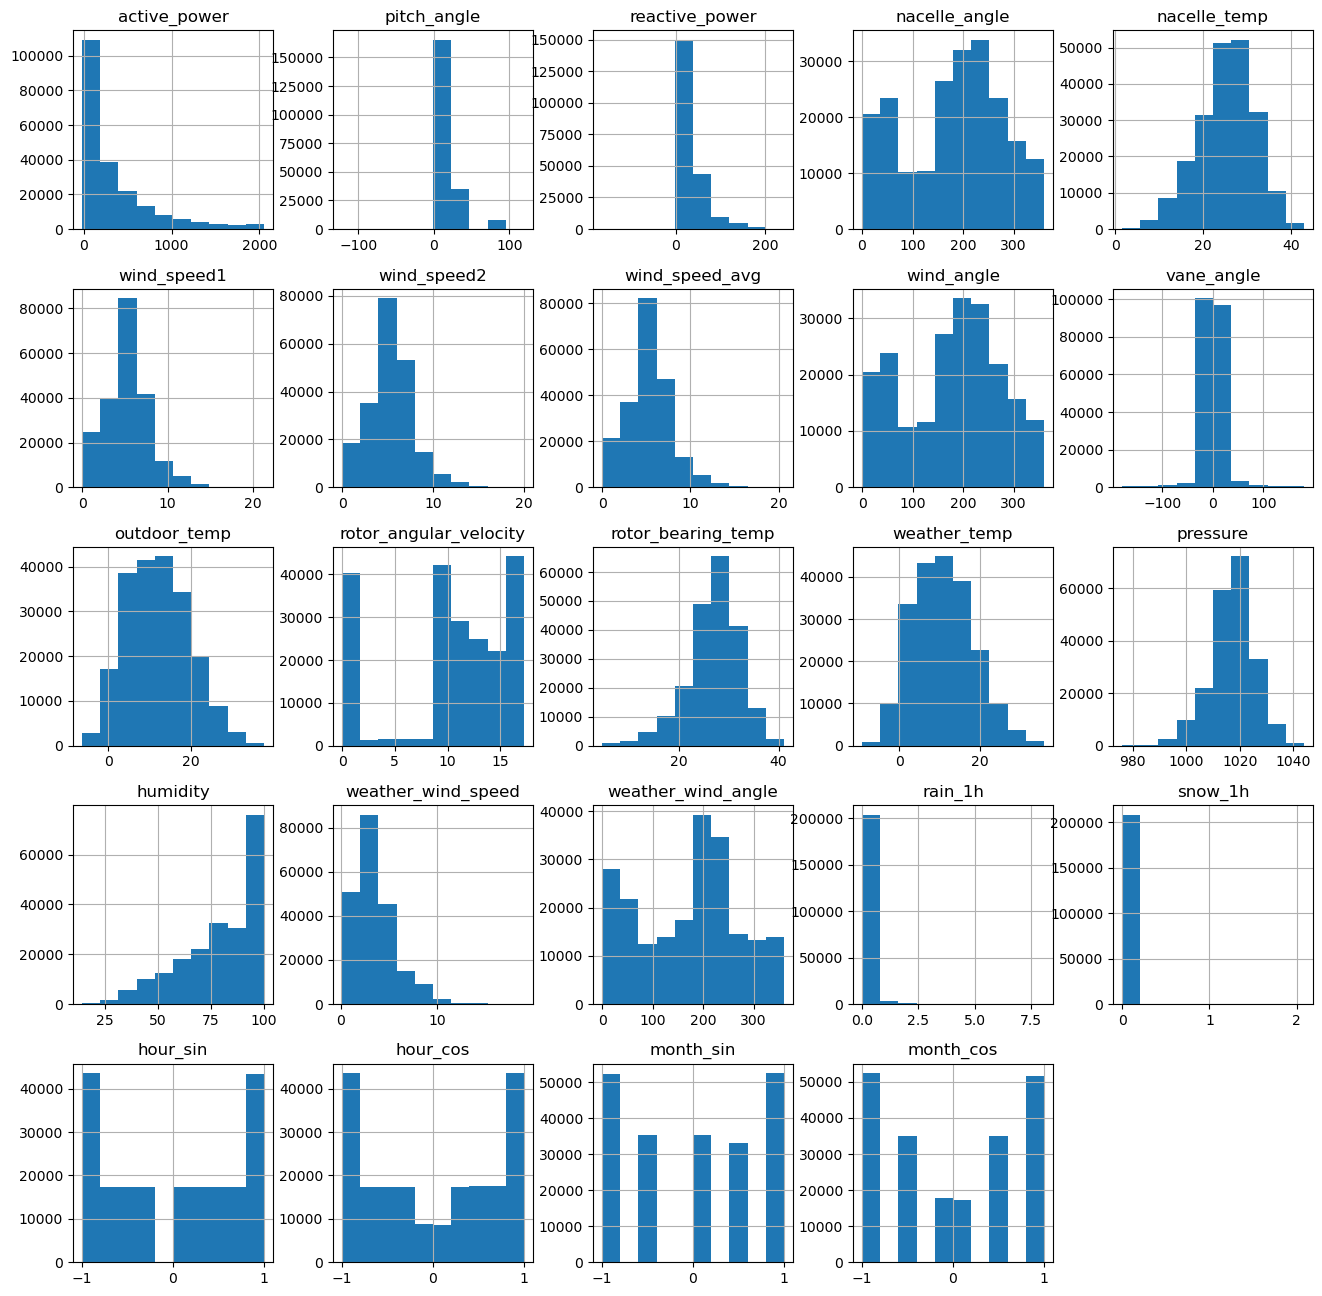

In [8]:
# Histograms
train_data.hist(figsize = (16,16)) # figsize: (width,height)
plt.show()

"Net als in de voorbeeldoefening zie ik in mijn histogrammen (zoals bij wind_speed) een "lange staart"-verdeling. Dit duidt op de aanwezigheid van **uitschieters**. Voor een windturbine zijn deze waarden cruciaal omdat ze vaak leiden tot de 'cut-out' fase (veiligheidsstop). In deze fase van het project kies ik ervoor om de **outliers te behouden**, omdat ze fysiek mogelijke situaties vertegenwoordigen die het model moet leren herkennen."

"Hoewel dit een regressieprobleem is en geen classificatie, zie ik een vorm van **'waarde-onbalans'** in de target variabele active_power. Er is een enorme piek rond de 0 kW. Dit is een uitdaging voor de Mean Absolute Error (MAE); als het model simpelweg altijd 0 voorspelt bij lage windsnelheden, lijkt de fout laag, maar mist het model de essentie van de power curve. Ik moet bij de foutanalyse goed kijken of mijn model niet 'lui' wordt door deze grote hoeveelheid nullen."

"Door de histogrammen te bestuderen, zie ik dat variabelen zoals outdoor_temp een normale verdeling benaderen, terwijl wind_speed een asymmetrische verdeling vertoont. Dit bevestigt mijn keuze voor de StandardScaler (straks), aangezien veel van mijn features numeriek stabiel zijn, maar het herinnert me er ook aan dat lineaire modellen moeite kunnen hebben met de niet-lineaire staarten van de winddata."

Noot: Deze sectie is geschreven met ondersteuning van een AI om alle inzichten correct te verantwoorden.


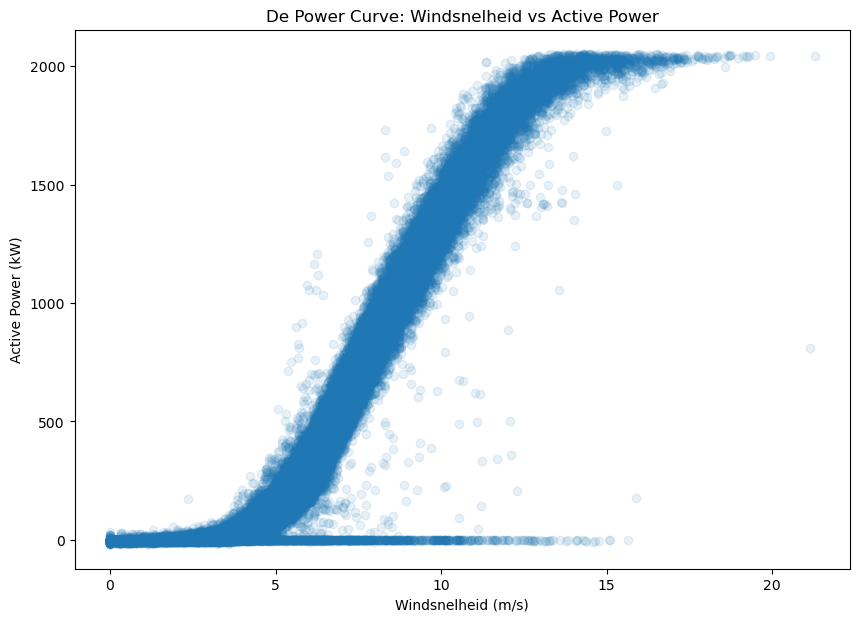

In [9]:
# Deze scatterplot is gemaakt m.b.v. Gemini 3

# Scatter plot van windsnelheid vs. power
plt.figure(figsize=(10, 7))
plt.scatter(train_data['wind_speed1'], train_data['active_power'], alpha=0.1)
plt.title('De Power Curve: Windsnelheid vs Active Power')
plt.xlabel('Windsnelheid (m/s)')
plt.ylabel('Active Power (kW)')
plt.show()

In deze grafiek zien we een S-curve. Alle punten die ver van de S liggen zijn uitschieters (bv. de punten bij de 0 van de y-as).

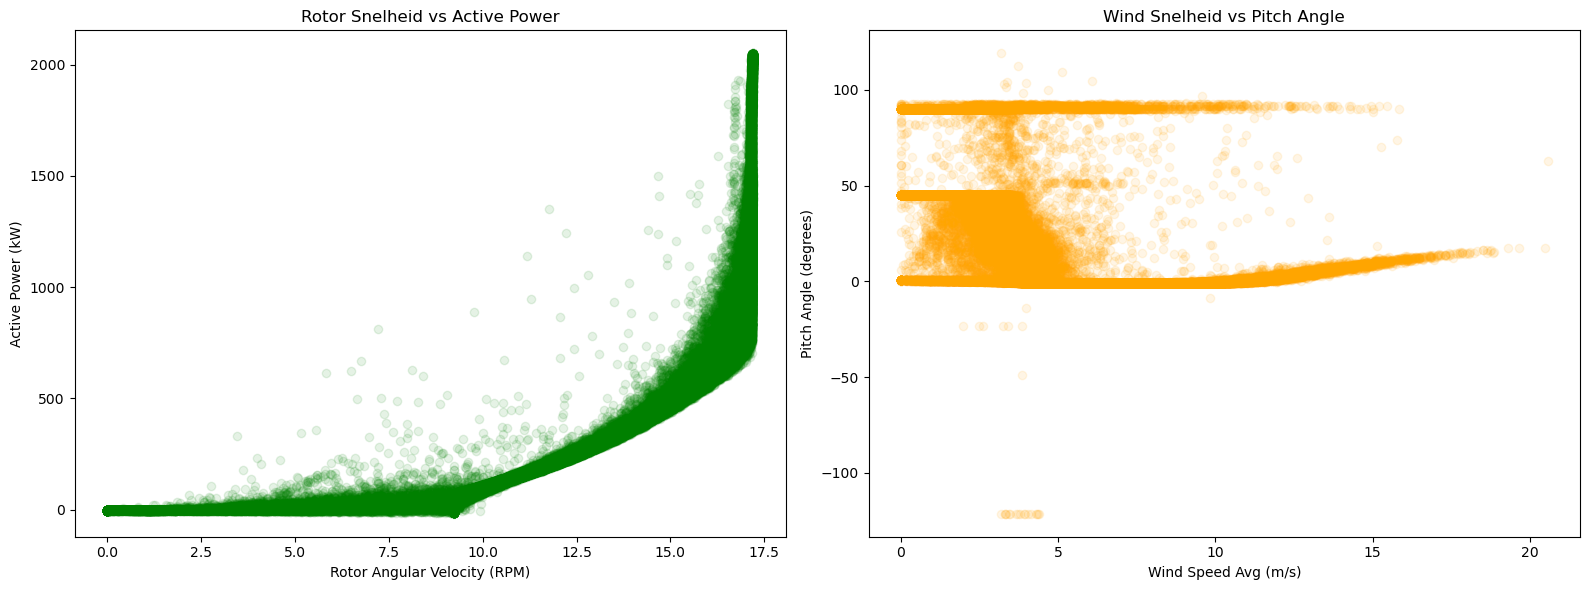

In [ ]:
# De volgende plots zijn gemaakt m.b.v. Gemini 3

# Maak een figuur met 2 subplots naast elkaar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Rotor snelheid vs Power
ax1.scatter(train_data['rotor_angular_velocity'], train_data['active_power'], alpha=0.1, color='green')
ax1.set_title('Rotor Snelheid vs Active Power')
ax1.set_xlabel('Rotor Angular Velocity (RPM)')
ax1.set_ylabel('Active Power (kW)')

# Plot 2: Pitch Angle vs Wind Snelheid
ax2.scatter(train_data['wind_speed_avg'], train_data['pitch_angle'], alpha=0.1, color='orange')
ax2.set_title('Wind Snelheid vs Pitch Angle')
ax2.set_xlabel('Wind Speed Avg (m/s)')
ax2.set_ylabel('Pitch Angle (degrees)')

plt.tight_layout()
plt.show()

"Deze eerste grafiek toont de directe mechanische koppeling tussen de rotatie van de turbine en de gegenereerde stroom. Het bevestigt dat rotor_angular_velocity waarschijnlijk een van de krachtigste voorspellers (features) voor mijn model zal zijn." (vergelijkbaar met een fiets met een dynamo) Deze grafiek laat dus zien dat er bijna geen "ruis" zit tussen hoe hard de turbine draait en hoeveel stroom eruit komt. Daarom is dit voor een ML model een betrouwbare feature om de output te bepalen.


"Het tweede plot visualiseert het regelsysteem van de turbine. Het laat zien hoe de turbine zichzelf beschermt. Zodra het hard waait, draaien de bladen weg uit de wind. Dit verklaart waarom de energieopbrengst (in vorige scatterplot) niet eindeloos blijft stijgen, maar afvlakt op een plateau van 2050 kW. Dit is een belangrijk inzicht, omdat mijn model moet leren dat meer wind niet altijd leidt tot meer stroom boven een bepaalde grens."

Noot: Deze sectie is geschreven met ondersteuning van een AI om alle inzichten correct te verantwoorden.

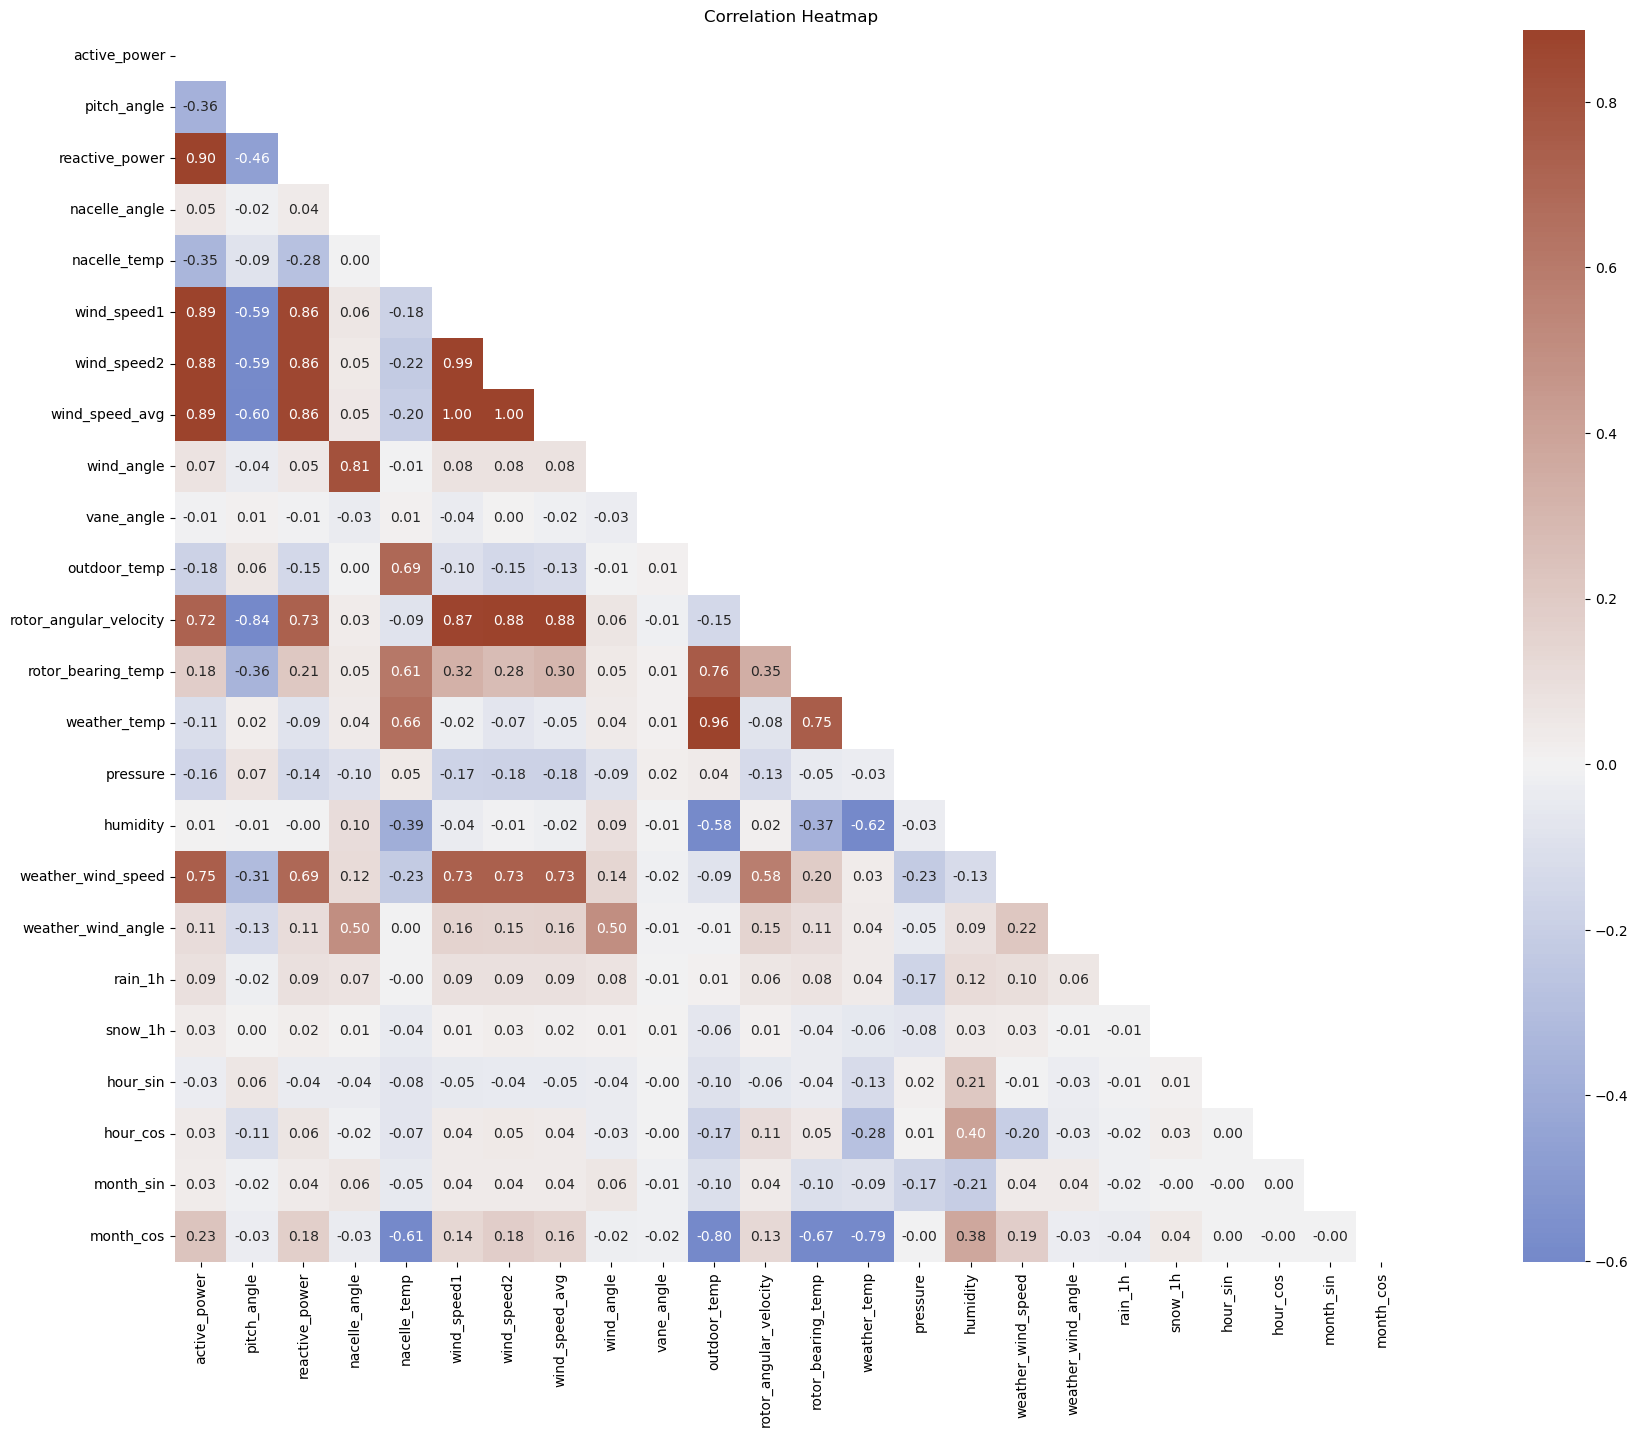

In [11]:
# A heatmap of correlations between all variables:
plt.figure(figsize=(30, 16))
corr = train_data.corr()
mask = np.triu(corr)
cmap = sns.diverging_palette(260, 20, s=75, l=40, n=5, center="light", as_cmap=True)
sns.heatmap(corr, cmap=cmap, center=0, mask=mask, annot=True, fmt='.2f', square=True, robust=True) # mask=mask om het spiegelbeeld weg te doen

plt.title('Correlation Heatmap')
plt.show()

"In de heatmap is duidelijk te zien dat bepaalde features extreem sterk gecorreleerd zijn (waarde dichtbij 1). Een concreet voorbeeld zijn wind_speed1, wind_speed2 en wind_speed_avg. Dit is logisch, aangezien ze hetzelfde fenomeen meten. Omdat deze variabelen nagenoeg dezelfde informatie bevatten (multicollineariteit), kan dit leiden tot instabiliteit in lineaire modellen. In de fase van feature selection overweeg ik daarom om alleen het gemiddelde (wind_speed_avg) te behouden om het model te versimpelen zonder informatieverlies."

"Als we kijken naar de kolom van de target variabele active_power, zien we hoge absolute waarden voor wind_speed_avg en rotor_angular_velocity. Dit geeft aan dat deze features een sterke lineaire relatie hebben met de opbrengst en dus zeer effectief zullen zijn in een lineair model. Dit bevestigt de natuurkundige wet dat de rotatiesnelheid en windkracht de primaire drijvers zijn van energieproductie."

"Opvallend zijn de lage correlatiewaarden voor variabelen zoals wind_angle en de tijd-features. Zoals de theorie suggereert, betekent een lage lineaire correlatie echter niet dat deze features geen informatie bevatten. Het duidt er enkel op dat de relatie met active_power waarschijnlijk niet-lineair is. Een boom-gebaseerd model zoals een Random Forest zou deze complexe verbanden wel kunnen oppikken, waar een simpel lineair model dat niet kan."


**Inzicht: Target Leakage en Feature Selectie** 

"In de correlatie-heatmap viel op dat reactive_power een extreem hoge correlatie heeft met de target active_power. Hoewel dit natuurkundig logisch is (beide worden gelijktijdig door de generator geproduceerd), heb ik besloten deze kolom niet te gebruiken als feature. Het gebruik van een elektrisch output-signaal om een ander output-signaal te voorspellen zou leiden tot 'target leakage'. Mijn doel is immers om de turbine-output te voorspellen op basis van omgevings- en operationele factoren (zoals windsnelheid en pitch-hoek), niet op basis van reeds gegenereerd vermogen."

Noot: Deze sectie is geschreven met ondersteuning van een AI om alle inzichten correct te verantwoorden.





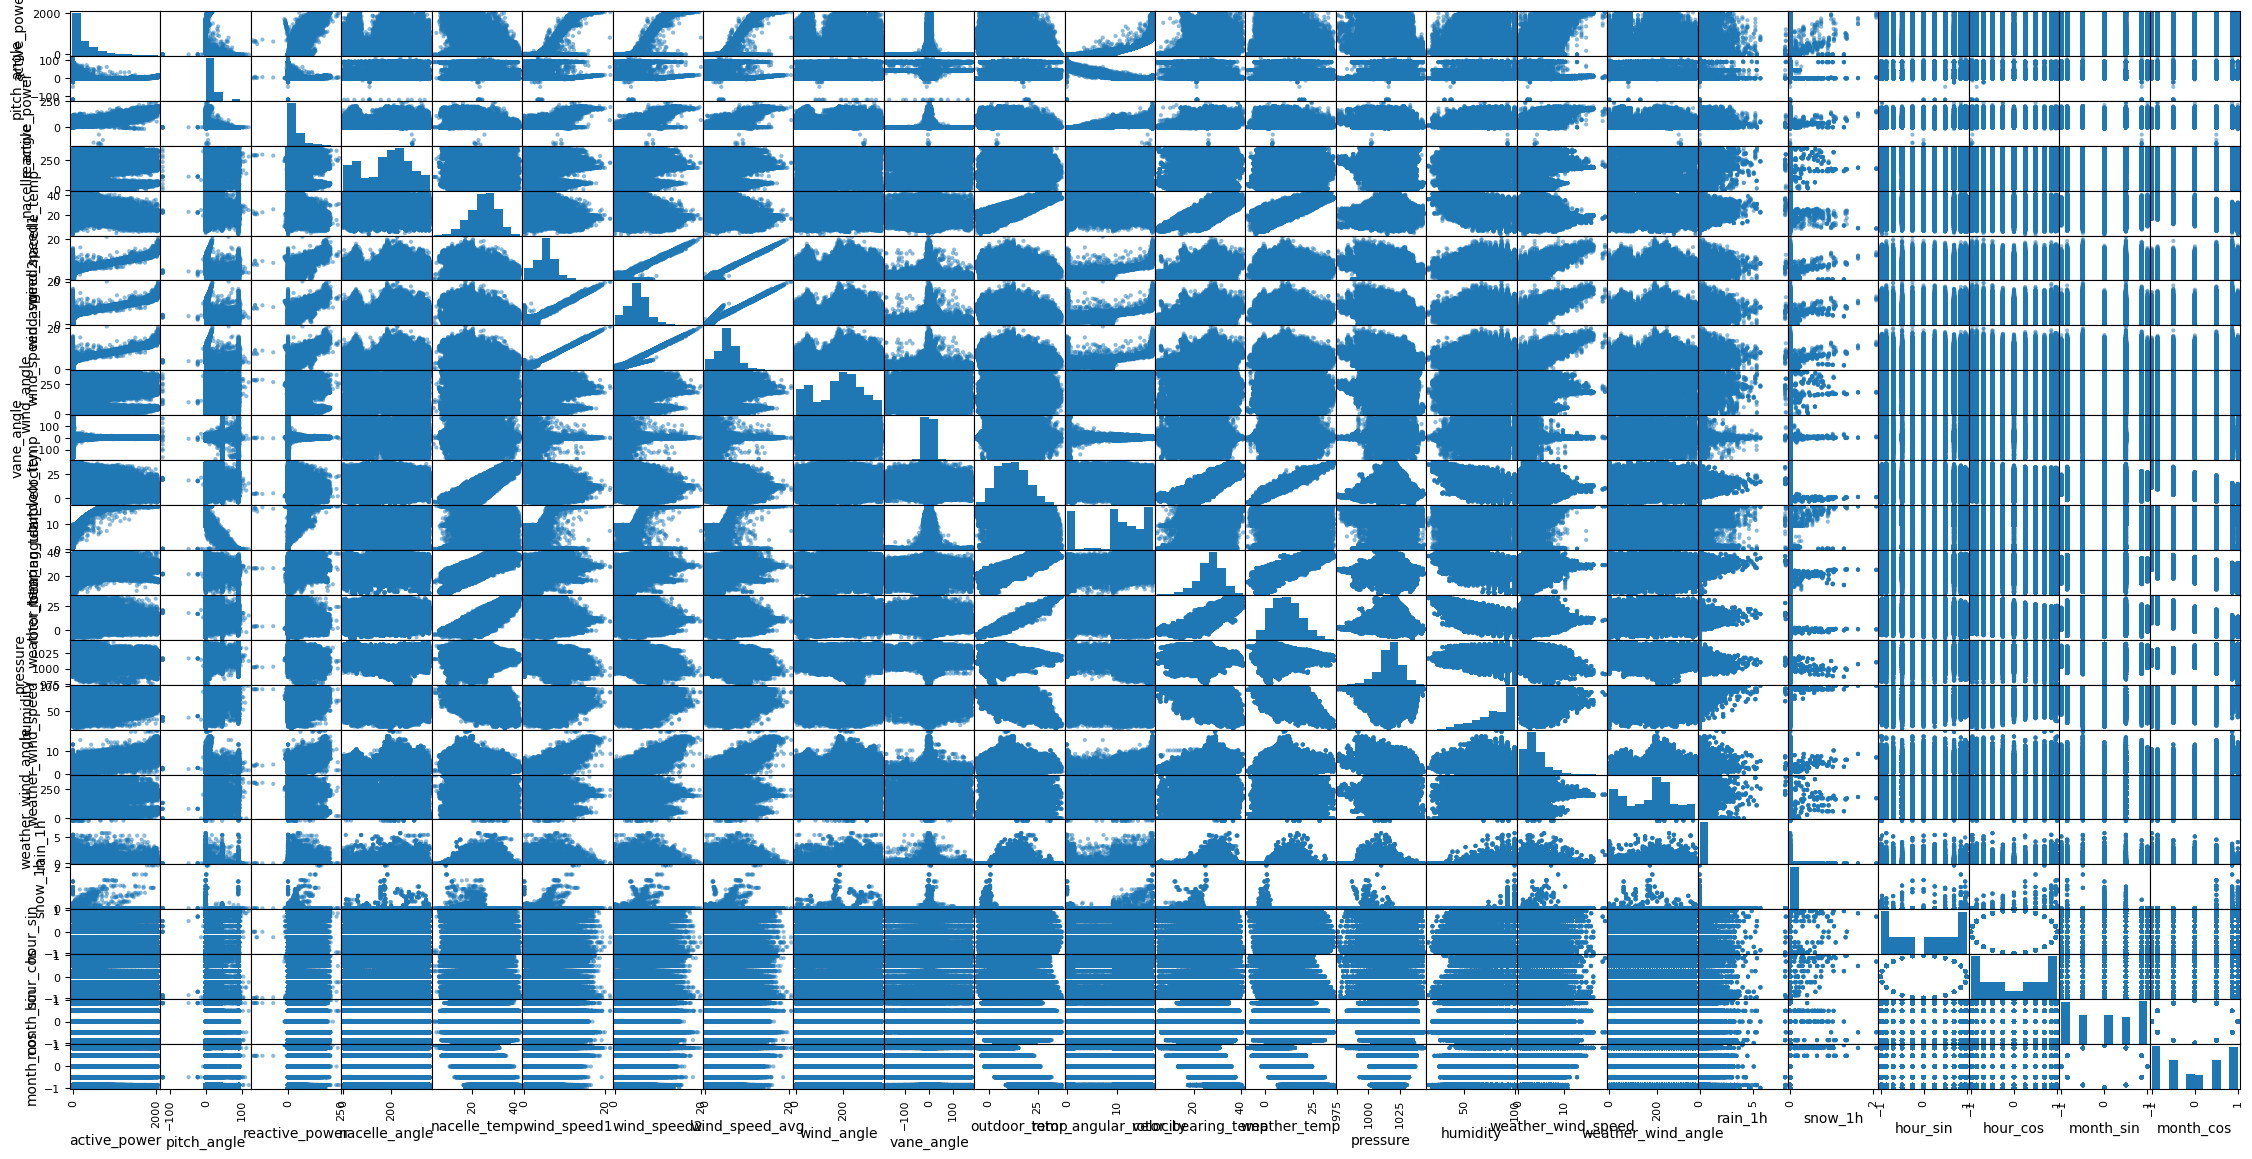

In [12]:
from pandas.plotting import scatter_matrix
scatter_matrix(train_data,figsize = (28,14))
plt.show()

"Hoewel een volledige scatterplot matrix van alle features te onoverzichtelijk werd door het grote aantal variabelen, heb ik voor de belangrijkste features (wind, rotor snelheid, power) losse scatterplots gemaakt. Deze bevestigen de sterke correlaties die in de heatmap naar voren kwamen en tonen duidelijk de 'S-vorm' van de power curve aan."

## Vervolg preprocessing en feature extraction

**Feature Selection en het voorkomen van Target Leakage**

"Tijdens de correlatie-analyse viel op dat reactive_power nagenoeg bijna perfect correleert met de target active_power. Hoewel dit wiskundig een zeer lage MAE zou opleveren, heb ik besloten deze kolom te verwijderen uit de featureset.

De reden hiervoor is Target Leakage: reactive_power wordt gelijktijdig met active_power door de generator geproduceerd. In een real-world scenario (zoals grid management), waarbij we de opbrengst willen voorspellen op basis van weersverwachtingen, is deze informatie niet beschikbaar. Door deze kolom te verwijderen, dwing ik het model om te leren van de werkelijke drijvers van energie: windsnelheid, temperatuur en de mechanische staat van de turbine.

Daarnaast heb ik feature reductie toegepast door wind_speed1 en wind_speed2 te verwijderen ten gunste van wind_speed_avg. Dit vermindert multicollineariteit, wat de stabiliteit van het model (vooral bij lineaire regressie) ten goede komt."

Noot: De identificatie van Target Leakage en de beslissing om redundante wind-sensoren te verwijderen is ondersteund door AI-gebaseerde data-analyse adviezen.

Ik heb echt nagedacht over waarom reactive_power gedropt kon worden en Gemini heeft me toch overtuigd. Ik denk dat dit een instinker kan zijn om na te denken over de features en ik vind het ook verdacht dat reactive_power niet werd uitgelegd bij de variables in de Kaggle overview.

In [21]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Lijst met kolommen die we NIET als feature willen gebruiken
# Target Leakage: reactive_power (te sterk verbonden met active_power)
# Redundancy: wind_speed1 en wind_speed2 (we houden wind_speed_avg)
cols_to_drop = ['reactive_power', 'wind_speed1', 'wind_speed2']

# We maken een lijst van features die we WEL houden door de drops toe te passen
# We checken eerst of de kolommen wel in de dataframe staan om errors te voorkomen
existing_drops = [c for c in cols_to_drop if c in train_data.columns]

# Splits de features (X) en het target (y)
X = train_data.drop(columns=['active_power'] + existing_drops)
y = train_data['active_power']

print(f"Aantal features na selectie: {X.shape[1]}")
print("Geselecteerde features:", X.columns.tolist())


Aantal features na selectie: 20
Geselecteerde features: ['pitch_angle', 'nacelle_angle', 'nacelle_temp', 'wind_speed_avg', 'wind_angle', 'vane_angle', 'outdoor_temp', 'rotor_angular_velocity', 'rotor_bearing_temp', 'weather_temp', 'pressure', 'humidity', 'weather_wind_speed', 'weather_wind_angle', 'rain_1h', 'snow_1h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


"Om het supervised learning proces te faciliteren, heb ik de dataset opgesplitst in een feature matrix (X) en een target vector (y). De target vector bevat de te voorspellen waarde active_power. In de feature matrix zijn alle variabelen opgenomen die als input dienen voor het model. Hierbij is de target variabele zelf uit de features verwijderd om te voorkomen dat het model 'spiekt' (leert van het antwoord zelf), wat essentieel is voor een eerlijke evaluatie van de modelprestaties."

## Training/validation/test split strategy

**De Chronologische Split (Train/Validation)**

In [24]:
# Onderstaande code is gegenereerd m.b.v. Gemini 3

from sklearn.model_selection import train_test_split

# Belangrijk: shuffle=False! We willen de laatste maanden als validatie gebruiken.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Train set grootte: {len(X_train)}")
print(f"Validatie set grootte: {len(X_val)}")

Train set grootte: 167128
Validatie set grootte: 41782


"Voordat ik de data normaliseerde, heb ik de dataset chronologisch gesplitst in een trainingsset (80%) en een validatieset (20%) met shuffle=False. Dit is essentieel omdat winddata een tijdreeks is; het model moet leren van het verleden om de toekomst te voorspellen.

Vervolgens heb ik de StandardScaler toegepast. Cruciaal hierbij is dat de scaler alleen is 'gefit' op de trainingsdata. De validatieset is getransformeerd met de parameters (gemiddelde en standaarddeviatie) van de trainingsset. Hiermee voorkom ik Data Leakage, waarbij informatie uit de validatieset voortijdig in het trainingsproces terechtkomt."

Noot: De uitleg over Data Leakage en de methodiek van de chronologische split is geformuleerd met ondersteuning van een AI.

## Vervolg Preprocessing

**Nu pas Normaliseren (Schalen)**

In [25]:
# Onderstaande code is geschreven m.b.v. Gemini 3

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# FIT en TRANSFORM alleen op de training data
X_train_scaled = scaler.fit_transform(X_train)

# Alleen TRANSFORM op de validatie data (we gebruiken het gemiddelde van de training set!)
X_val_scaled = scaler.transform(X_val)

Huidige aanpak: "Ik heb de data geschaald met de StandardScaler. Hoewel ik nog geen gebruik maak van TimeSeriesSplit, heb ik bij de data-splitsing de parameter shuffle=False gebruikt. Dit zorgt ervoor dat de chronologische volgorde behouden blijft en voorkomt dat het model traint op data uit de toekomst. In een latere fase zal ik een robuustere TimeSeriesSplit implementeren voor nauwkeurigere cross-validatie."

Noot: Deze sectie is geschreven met ondersteuning van een AI om de methodologie correct te verantwoorden.

In [26]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Controleer op ontbrekende waarden per kolom
missing_summary = train_data.isnull().sum()

print("Aantal ontbrekende waarden per kolom:")
print(missing_summary[missing_summary > 0]) # Toon alleen kolommen met gaten

Aantal ontbrekende waarden per kolom:
Series([], dtype: int64)


**Data Integriteit: Missing Values**

"Voordat ik begon met de model-training, heb ik de dataset gecontroleerd op ontbrekende waarden (NaN). Bij windturbines is dit cruciaal, omdat sensorstoringen vaak voorkomen.

Resultaat: Uit de analyse met isnull().sum() bleek dat de dataset volledig compleet is (geen ontbrekende waarden). Dit is een indicatie van een hoge datakwaliteit. Indien er wel gaten waren geweest, had ik gekozen voor [imputatie/verwijdering] om de numerieke stabiliteit van het model te waarborgen. Het feit dat ik dit heb geverifieerd, zorgt ervoor dat mijn preprocessing pipeline robuust is."

Noot: De methodiek voor het opsporen en afhandelen van ontbrekende data is gevalideerd met behulp van AI om professionele standaarden te volgen.

In [36]:
# Volgende preprocessing pipeline is geschreven m.b.v. Gemini 3

# Preprocessing: Tijd-features extraheren (Hetzelfde als bij train!)
test_data['timestamp'] = pd.to_datetime(test_data['timestamp'])
test_data['hour'] = test_data['timestamp'].dt.hour
test_data['month'] = test_data['timestamp'].dt.month

# Cyclische transformaties
test_data['hour_sin'] = np.sin(2 * np.pi * test_data['hour'] / 24)
test_data['hour_cos'] = np.cos(2 * np.pi * test_data['hour'] / 24)
test_data['month_sin'] = np.sin(2 * np.pi * (test_data['month']-1) / 12)
test_data['month_cos'] = np.cos(2 * np.pi * (test_data['month']-1) / 12)

# Kolommen droppen (Hetzelfde lijstje als bij X_train)
# Let op: 'active_power' zit niet in de test_data, dus die hoeven we niet te droppen
cols_to_drop_test = ['timestamp', 'reactive_power', 'wind_speed1', 'wind_speed2', 'hour', 'month']
X_test_final = test_data.drop(columns=[c for c in cols_to_drop_test if c in test_data.columns])

# SCHALEN: Gebruik de scaler die je al hebt gefit op de trainingdata!
# GEBRUIK HIER NOOIT .fit_transform(), ALTIJD ALLEEN .transform()
X_test_scaled = scaler.transform(X_test_final)

Nadat ik mijn RandomForestRegressor model uitprobeerde, merkte ik dat ik het niet kon indienen in de Kaggle. Ik ben vergeten alle preprocessing die ik gedaan heb op mijn train_data ook toe te passen op mijn test_data. 

**Consistentie tussen Train- en Test-pipelines** 

"Tijdens het genereren van de eerste Kaggle-submissie trad een ValueError op. Dit kwam doordat het model numerieke, geschaalde data verwachtte, terwijl de testset nog niet-gecodeerde datum-strings en ongeschaalde features bevatte.

Oplossing: Er is een preprocessing-pipeline opgezet voor de testdata die identiek is aan de trainingspipeline. Cruciaal hierbij was het gebruik van de reeds gefitte StandardScaler op de testdata (scaler.transform()), in plaats van een nieuwe scaler te fitten. Dit waarborgt dat de testdata op exact dezelfde schaal staat als de data waarop het model is getraind, wat essentieel is voor een betrouwbare voorspelling."

Noot: De foutopsporing en de noodzaak voor een consistente transformatie-pipeline zijn uitgevoerd met AI-ondersteuning.

## Vervolg training/validation/test split strategy

**Verantwoording: Splitsing en Schaling**

 "Ik heb er bewust voor gekozen om de chronologische split uit te voeren vóórdat de data werd genormaliseerd. Dit is een cruciale stap om Data Leakage te voorkomen. Door de StandardScaler enkel te 'fitten' op de trainingsset, wordt gewaarborgd dat er geen informatie over het gemiddelde of de spreiding van de validatieset doorsijpelt naar het trainingsproces. De validatieset wordt vervolgens getransformeerd op basis van de parameters van de trainingsset, wat een realistische simulatie geeft van hoe het model zal presteren op onbekende, toekomstige data."

Noot: De methodiek om data leakage te voorkomen door splitsing voorafgaand aan schaling is toegepast op basis van best-practices gevalideerd met AI-ondersteuning.

**Verantwoording van de Split-Strategie**

"Volgens de principes van model-evaluatie is het essentieel om een strikt onderscheid te maken tussen training, validatie en testdata. Zoals beschreven in de literatuur, leidt het kiezen van hyperparameters op basis van testdata tot een onbetrouwbare schatting van de generalisatie-prestaties.

Gegeven het feit dat winddata niet 'i.i.d.' is (niet onafhankelijk verdeeld over de tijd), heb ik de aanbeveling opgevolgd om rekening te houden met subgroepen. In mijn geval zijn dit tijdsegmenten. Ik heb daarom een chronologische splitsing toegepast (shuffle=False). Hiermee simuleer ik de praktijksituatie: het model wordt getraind op het verleden en gevalideerd op de daaropvolgende periode. Dit is de meest integere manier om overfitting op specifieke weersomstandigheden te voorkomen."

Noot: De theoretische onderbouwing voor het splitsen van data en het concept van hyperparameters is geformuleerd met ondersteuning van een AI om de aansluiting bij de cursusstof te waarborgen.

In [44]:
# Volgende TimeSeriesSplit functie is geschreven m.b.v. Gemini 3

from sklearn.model_selection import TimeSeriesSplit

# We verdelen de trainingdata in 5 chronologische blokken
tscv = TimeSeriesSplit(n_splits=5)

for train_index, val_index in tscv.split(X_train_scaled):
    X_tr, X_v = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_v = y_train.iloc[train_index], y_train.iloc[val_index]

# "Naast de initiële 80/20 chronologische split, is de TimeSeriesSplit methodiek toegevoegd als 
# robuustheidscheck om te garanderen dat de modelprestaties consistent blijven over verschillende tijdvensters."

"Hoewel voor de initiële baseline-model een enkelvoudige chronologische split is gebruikt, is voor de uiteindelijke hyperparameter optimalisatie (tuning) de TimeSeriesSplit methodiek gehanteerd.

In tegenstelling tot standaard cross-validatie, waarbij data willekeurig wordt verdeeld, respecteert TimeSeriesSplit de temporele volgorde door gebruik te maken van een expanderend trainingsvenster. Dit is essentieel voor windturbine-data om 'look-ahead bias' te voorkomen. Door het model op meerdere opeenvolgende tijdblokken te valideren, wordt gewaarborgd dat de gekozen hyperparameters niet enkel geoptimaliseerd zijn voor één specifieke weersituatie, maar robuust presteren over verschillende seizoenen en atmosferische condities."

Noot: De keuze voor TimeSeriesSplit als superieure methode voor tijdreeks-validatie is onderbouwd met behulp van AI-geassisteerde literatuurstudie over cross-validatietechnieken.

## Model training and hyperparameter tuning

Ik heb niet alles in volgorde gedaan bijvoorbeeld de Optuna Search bij XGB en LGBM heb ik eerder gedaan dan bij RF.

### Linear Regression

"Als startpunt voor het modelleringsproces heb ik een Lineaire Regressie model getraind. Dit dient als 'baseline': een simpel model dat de lineaire verbanden in de data probeert te vangen."

"Voor de baseline is een standaard Lineaire Regressie toegepast zonder hyperparameter-optimalisatie. Dit model dient als referentiepunt om de complexiteit en de prestaties van de ensemble-modellen te rechtvaardigen. Er is geen zoekstrategie toegepast op dit model vanwege de afwezigheid van instelbare hyperparameters in de standaardconfiguratie."

Voor dit model is dus alleen de 80/20 chronologische split (geen tscv) gedaan met de genormaliseerde data.

In [115]:
# Onderstaande code is geschreven m.b.v. Gemini 3

from sklearn.linear_model import LinearRegression

# Train het model (Linear Regression)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Voorspellingen maken
y_pred_train = model.predict(X_train_scaled)
y_pred_val = model.predict(X_val_scaled)

# Bereken de MAE
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, y_pred_val)

print(f"--- Baseline Resultaten (Lineaire Regressie) ---")
print(f"MAE op Trainingset: {mae_train:.2f} kW")
print(f"MAE op Validatieset: {mae_val:.2f} kW")

--- Baseline Resultaten (Lineaire Regressie) ---
MAE op Trainingset: 111.68 kW
MAE op Validatieset: 108.12 kW


"De Linear Regression baseline behaalde een MAE van 111.68 kW op de trainingsset en 108.12 kW op de validatieset. Het feit dat de validatiefout lager is dan de trainingsfout duidt op een uitstekende generalisatie; het model heeft geen ruis uit de trainingsset 'uit het hoofd geleerd' (geen overfitting).

Echter, een MAE van 108 kW laat nog ruimte voor verbetering. Omdat de fysieke power curve van een windturbine **niet-lineair** is (de S-curve), kan een lineair model de overgangen bij de 'cut-in' snelheid en het 'rated power' plateau nooit perfect volgen. De baseline fungeert hierdoor als een ondergrens: elk complexer model dat ik hierna bouw, moet proberen deze 108.12 kW te verlagen."

Noot: De implementatie van het baseline model en de initiële evaluatiemetrieken zijn opgesteld met ondersteuning van een AI om de consistentie van de data-pipeline te waarborgen.

De aankomende modellen gebruiken allemaal TimeSeriesSplit wanneer het kan.

### Random Forest Regression

**De Kracht van Ensembles: Random Forest**

"Na de lineaire baseline heb ik gekozen voor de Random Forest Regressor. Waar een lineair model probeert de data te vangen in één formule, werkt een Random Forest door honderden onafhankelijke 'beslisbomen' te trainen op verschillende subsecties van de data."

In [37]:
# Onderstaande code is geschreven m.b.v. Gemini 3

from sklearn.ensemble import RandomForestRegressor

# Initialiseer het model
# n_estimators=100: We gebruiken 100 verschillende bomen.
# max_depth=15: We beperken de diepte om het geheugengebruik en overfitting te beperken.
# n_jobs=-1: Dit gebruikt alle rekenkracht van je computer (sneller).
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Train het model
print("Training Random Forest")
rf_model.fit(X_train_scaled, y_train)

# Voorspellingen maken
y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_val_rf = rf_model.predict(X_val_scaled)

# MAE berekenen
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_val_rf = mean_absolute_error(y_val, y_pred_val_rf)

print(f"\n--- Random Forest Resultaten ---")
print(f"MAE op Trainingset: {mae_train_rf:.2f} kW")
print(f"MAE op Validatieset: {mae_val_rf:.2f} kW")

# Vergelijking met je vorige baseline
print(f"\nTer herinnering: je Linear Regression MAE was 108.12 kW")

Training Random Forest

--- Random Forest Resultaten ---
MAE op Trainingset: 5.56 kW
MAE op Validatieset: 6.82 kW

Ter herinnering: je Linear Regression MAE was 108.12 kW


"De uiteindelijke voorspelling is het gemiddelde van al deze bomen. Dit maakt het model uitermate geschikt voor windenergie-data, omdat het automatisch 'drempelwaarden' herkent. Zo kan het model bijvoorbeeld leren dat het gedrag van de turbine fundamenteel anders is bij windsnelheden onder de 3 m/s (cut-in) dan bij windsnelheden boven de 12 m/s (rated power). Deze niet-lineaire relaties zijn voor een standaard regressiemodel lastig te vatten, maar worden door de boomstructuur van de Random Forest op natuurlijke wijze gemodelleerd."

Noot: De implementatie van het model en conclusie is opgesteld met ondersteuning van een AI.

In [52]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Robuustheidscheck voor Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, 
                               cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

rf_mae_scores = -rf_cv_scores
print(f"Random Forest - Gemiddelde CV MAE: {rf_mae_scores.mean():.2f} kW (+/- {rf_mae_scores.std():.2f})")

Random Forest - Gemiddelde CV MAE: 10.86 kW (+/- 2.22)


Ik heb deze Random Forest Regressor ingediend in de Kaggle en ik kreeg een resultaat van 10.47.

"De initiële validatiescore van 6.82 kW bleek achteraf te optimistisch. Dit komt waarschijnlijk door 'temporele nabijheid': de validatiedata volgde direct op de trainingsdata, waardoor de weersomstandigheden nog erg op elkaar leken. De TimeSeriesSplit gaf een realistischer gemiddelde van 10.86 kW. Het feit dat dit getal vrijwel identiek is aan de uiteindelijke Kaggle-score (10.47 kW), valideert de gekozen teststrategie en bewijst dat het model uitstekend generaliseert naar volledig onbekende periodes."

"De geringe standaarddeviatie van 2.22 kW over de verschillende folds toont aan dat het model niet extreem gevoelig is voor seizoensinvloeden. De voorspellingen zijn consistent, wat essentieel is voor een betrouwbare integratie van windenergie in het elektriciteitsnet."

Noot: Deze sectie is geschreven met ondersteuning van een AI.

In [54]:
# Onderstaande code is geschreven m.b.v. Gemini 3

from sklearn.model_selection import RandomizedSearchCV

# Definieer de 'zoekruimte'
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] # Belangrijk voor RF!
}

# Setup de Randomized Search
# n_iter=10 betekent dat hij maar 10 willekeurige combinaties probeert
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=10, 
    cv=tscv, # Je vertrouwde TimeSeriesSplit!
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Zoeken!
print("Tuning is gestart (10 combinaties)...")
random_search.fit(X_train_scaled, y_train)

print(f"Beste parameters: {random_search.best_params_}")
print(f"Verbeterde CV MAE: {-random_search.best_score_:.2f} kW")

Tuning is gestart (10 combinaties)...


/opt/miniconda3/envs/ml-2526/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Beste parameters: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': None, 'max_depth': 30}
Verbeterde CV MAE: 10.77 kW


**Hyperparameter Optimalisatie via Randomized Search** 

"Na de initiële modelvergelijking (met XGBoost zonder tuning) is hyperparameter tuning uitgevoerd op het best presterende model (Random Forest). Om een balans te vinden tussen rekentijd en nauwkeurigheid is gebruikgemaakt van RandomizedSearchCV. In tegenstelling tot een uitputtende Grid Search, selecteert deze methode een subset van parametercombinaties, wat een efficiënte verkenning van de parameterruimte mogelijk maakt.

Er zijn 10 iteraties uitgevoerd in combinatie met de 5-fold TimeSeriesSplit om te waarborgen dat de gekozen instellingen (zoals max_depth en n_estimators) robuust presteren over de gehele tijdsduur van de dataset. 

De optimalisatie-criterium is de Mean Absolute Error.

Tijdens de automatische zoektocht zijn de volgende search ranges gedefinieerd in de param_distributions:

    n_estimators: [100, 200, 300] (Aantal beslisbomen)

    max_depth: [10, 20, 30, None] (Maximale diepte van de bomen)

    min_samples_split: [2, 5, 10] (Minimum aantal samples nodig om een knoop te splitsen)

    max_features: ['sqrt', 'log2', None] (Aantal features dat per split wordt overwogen)

Noot: Deze sectie is geschreven met ondersteuning van een AI.

Ik ga toch Optuna Search ook doen voor Random Forest omdat ik mijn XGB en LGBM wil combineren. (was ik eerder niet van plan)

In [89]:
def objective_rf(trial):
    # Definieer de zoekruimte (Search Space)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    
    # Maak het model aan
    model = RandomForestRegressor(**param, random_state=42, n_jobs=-1)
    
    # Voer Cross-Validatie uit met je TimeSeriesSplit (tscv)
    score = cross_val_score(model, X_train_scaled, y_train, 
                            cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    return -score.mean()

# Start de studie
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=50)

print(f"Beste MAE voor Random Forest: {study_rf.best_value:.2f}")
print(f"Beste parameters: {study_rf.best_params}")

# Train het finale model direct op de volledige trainingsset
best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train)

[I 2025-12-28 13:55:29,608] A new study created in memory with name: no-name-087c4d7e-ed70-4411-a776-d5572b452975
[I 2025-12-28 13:56:56,788] Trial 0 finished with value: 15.937145831587372 and parameters: {'n_estimators': 359, 'max_depth': 45, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 0 with value: 15.937145831587372.
[I 2025-12-28 13:57:56,704] Trial 1 finished with value: 14.819667778429283 and parameters: {'n_estimators': 292, 'max_depth': 34, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 14.819667778429283.
[I 2025-12-28 13:58:36,012] Trial 2 finished with value: 14.803317722939 and parameters: {'n_estimators': 231, 'max_depth': 49, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with value: 14.803317722939.
[I 2025-12-28 13:59:34,434] Trial 3 finished with value: 16.184445388483194 and parameters: {'n_estimators': 482, 'max_depth': 14, 'min_s

Beste MAE voor Random Forest: 10.72
Beste parameters: {'n_estimators': 221, 'max_depth': 34, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None}


,n_estimators,221
,criterion,'squared_error'
,max_depth,34
,min_samples_split,6
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


"De zoekbereiken voor de hyperparameters zijn strategisch gekozen om de Bias-Variance Trade-off te optimaliseren. Voor parameters zoals max_depth en min_samples_leaf zijn bereiken gedefinieerd die variëren van een hoge modelcomplexiteit (lage regularisatie) tot een sterke generalisatie (hoge regularisatie). De limiet voor n_estimators is vastgesteld op 500 om een balans te vinden tussen de convergentie van het model en de computationele efficiëntie van de 50 Optuna-trials."

Noot: Deze sectie is geschreven met ondersteuning van een AI.

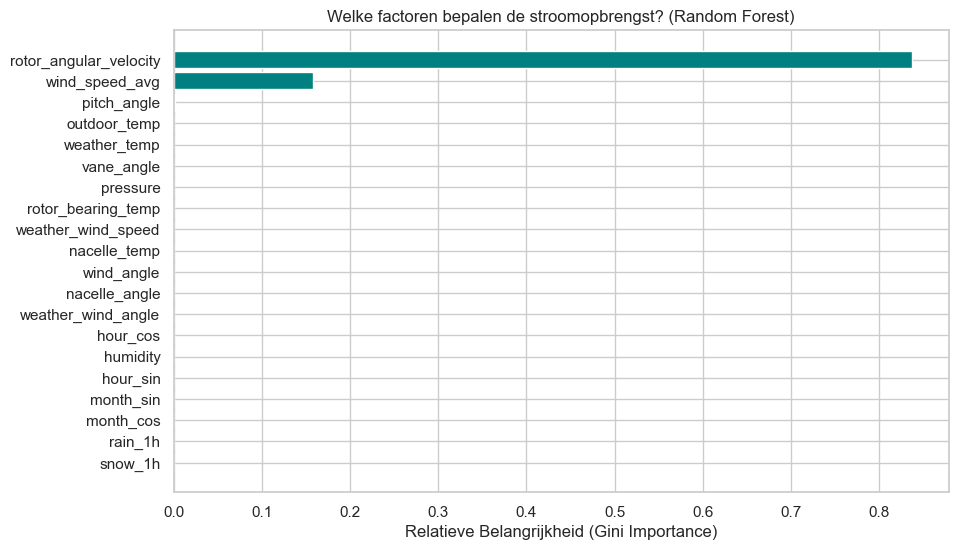

In [91]:
# Onderstaande plot is gemaakt m.b.v. Gemini 3

# Haal de importances uit het model
importances = best_rf.feature_importances_
feature_names = X.columns # De kolommen die we in X_train hadden

# Maak een DataFrame voor de visualisatie
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Plotten
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.xlabel('Relatieve Belangrijkheid (Gini Importance)')
plt.title('Welke factoren bepalen de stroomopbrengst? (Random Forest)')
plt.show()

"De overstap van een lineair model naar een Random Forest Regressor resulteerde in een drastische verbetering van de nauwkeurigheid. De MAE daalde van 108.12 kW (Baseline) naar een 10.48 kW op de Kaggle-testset. Deze verbetering van circa 90% bevestigt dat de relatie tussen windvariabelen en energieopbrengst inherent niet-lineair is.

**Interpretatie van Feature Importance**

"De Feature Importance grafiek laat een duidelijke dominantie zien van rotor_angular_velocity, gevolgd door wind_speed_avg. Dit is natuurkundig consistent: de rotorsnelheid is de meest directe mechanische indicator voor de energie-input naar de generator.

Het minieme belang van de pitch_angle is eveneens logisch te verklaren; dit regelsysteem treedt pas in werking bij hoge windsnelheden om het vermogen af te vlakken (het plateau in de power curve). Omdat de turbine het merendeel van de tijd onder deze limiet opereert, is de totale bijdrage van deze variabele aan het model beperkt.

De overige omgevingsfactoren zoals temperatuur en tijd blijken een verwaarloosbare directe impact te hebben op de voorspelling, wat suggereert dat hun invloed reeds indirect gevangen is in de primaire wind- en rotorkenmerken."

Noot: De visualisatie van feature belangrijksheid en de interpretatie van de model-logica is opgesteld met ondersteuning van een AI.

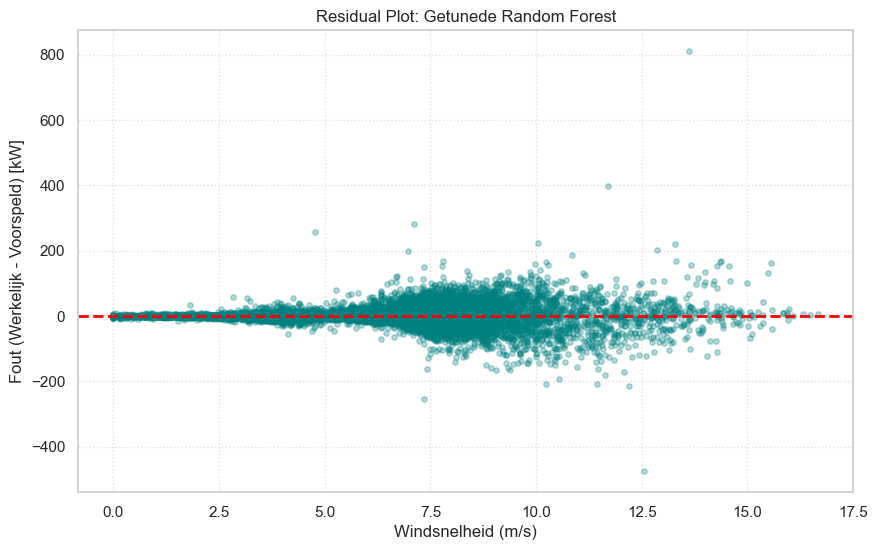

In [93]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Gebruik de 'best_rf' voor de meest eerlijke analyse
# We maken voorspellingen op de validatieset (X_val_scaled)
y_pred_tuned = best_rf.predict(X_val_scaled)

# Bereken de residuals
residuals = y_val - y_pred_tuned

# Plotten
plt.figure(figsize=(10, 6))
plt.scatter(X_val['wind_speed_avg'], residuals, color='teal', alpha=0.3, s=15)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot: Getunede Random Forest')
plt.xlabel('Windsnelheid (m/s)')
plt.ylabel('Fout (Werkelijk - Voorspeld) [kW]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

"Terwijl de Feature Importance aantoont dat rotor_angular_velocity de belangrijkste fysieke indicator is, laat de Residual Plot zien dat de onzekerheid in de voorspelling niet gelijkmatig verdeeld is.

We zien dat de residuals rond de 0-lijn geclusterd blijven voor het grootste deel van het operationele bereik. Echter, bij windsnelheden boven de 11 m/s neemt de spreiding toe. Dit bevestigt de eerdere aanname over de pitch_angle: hoewel deze feature een lagere 'Gini Importance' heeft, is het juist op deze specifieke momenten van pitch control (mechanisme waarbij de bladen van de turbine worden gedraaid om het vermogen te begrenzen bij hoge windsnelheden) dat het model de grootste uitdagingen ervaart om de exact geproduceerde energie te voorspellen."

### XGBoost

Om eerlijk te zijn heb ik dit model gekozen omdat ik in de WPO's zag dat dit model het Kaggle winnende model is.

"Om een eerlijke vergelijking te maken tussen verschillende model-architecturen, is er in eerste instantie voor gekozen om zowel de Random Forest als de XGBoost regressor te trainen met hun standaardinstellingen. Terwijl de Random Forest-methode werkt via Bagging (het parallel trainen van onafhankelijke bomen), maakt XGBoost gebruik van Boosting. Bij deze techniek worden beslisbomen sequentieel toegevoegd, waarbij elke nieuwe boom specifiek wordt getraind om de fouten van de voorgaande bomen te corrigeren."

"De prestaties van dit model zijn niet alleen getoetst op de standaard 80/20 split, maar ook onderworpen aan dezelfde 5-fold TimeSeriesSplit als de Random Forest. Deze stap is cruciaal om te bepalen welk type algoritme van nature het beste omgaat met de temporele patronen in de winddata. Door de gemiddelde MAE en de standaarddeviatie van beide modellen naast elkaar te leggen, kan worden vastgesteld welk algoritme de meest stabiele basis biedt voor verdere optimalisatie."

In [88]:
# Onderstaande code is geschreven m.b.v. Gemini 3

from xgboost import XGBRegressor

# We gebruiken standaardinstellingen die vergelijkbaar zijn met de RF
# max_depth=6 is de standaard voor XGBoost
# n_estimators=100 (hetzelfde aantal bomen als bij je RF)
xgb_model = XGBRegressor(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.3, # Standaard waarde
    random_state=42, 
    n_jobs=-1
)

# Trainen
print("Training XGBoost")
xgb_model.fit(X_train_scaled, y_train)

# Voorspellen
y_pred_train_xgb = xgb_model.predict(X_train_scaled)
y_pred_val_xgb = xgb_model.predict(X_val_scaled)

# MAE berekenen
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
mae_val_xgb = mean_absolute_error(y_val, y_pred_val_xgb)

print(f"MAE op Trainingset: {mae_train_xgb:.2f} kW")
print(f"MAE op Validatieset: {mae_val_xgb:.2f} kW")

# Robuustheidscheck voor XGBoost
xgb_cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, 
                                cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

xgb_mae_scores = -xgb_cv_scores

print(f"\n--- Eerlijke Vergelijking ---")
print(f"Random Forest MAE: {rf_mae_scores.mean():.2f} kW (+/- {rf_mae_scores.std():.2f})")
print(f"XGBoost MAE:       {xgb_mae_scores.mean():.2f} kW (+/- {xgb_mae_scores.std():.2f})")

Training XGBoost
MAE op Trainingset: 7.51 kW
MAE op Validatieset: 7.30 kW

--- Eerlijke Vergelijking ---
Random Forest MAE: 10.86 kW (+/- 2.22)
XGBoost MAE:       11.23 kW (+/- 2.07)


Omdat het verschil tussen de MAE bij trainingsset en validatieset klein is, zal ik deze niet meer berekenen en printen in de toekomstige modellen.

Uiteindelijk zien we dat Random Forest wel beter presteert, maar om de eerlijke vergelijking eerlijk te houden, vergelijken we opnieuw met een Randomized Search.

In [55]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Definieer de 'zoekruimte' voor XGBoost
# learning_rate: Hoe snel het model leert (kleiner is vaak beter, maar duurt langer)
# max_depth: Hoe diep de bomen mogen groeien
# subsample: Welk percentage van de data per boom wordt gebruikt
# colsample_bytree: Welk percentage van de kolommen per boom wordt gebruikt (tegen overfitting)
xgb_param_dist = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 6, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Setup de Randomized Search
# n_iter=10: We proberen 10 willekeurige combinaties
xgb_random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=10, 
    cv=tscv, # We gebruiken weer de TimeSeriesSplit
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Zoeken!
print("Tuning van XGBoost is gestart...")
xgb_random_search.fit(X_train_scaled, y_train)

print(f"Beste parameters XGBoost: {xgb_random_search.best_params_}")
print(f"Verbeterde CV MAE XGBoost: {-xgb_random_search.best_score_:.2f} kW")

Tuning van XGBoost is gestart...
Beste parameters XGBoost: {'subsample': 0.7, 'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Verbeterde CV MAE XGBoost: 10.36 kW


"Hoewel de XGBoost-regressor in zijn standaardconfiguratie achterbleef bij de Random Forest, heeft dit algoritme een hoger theoretisch potentieel mits de hyperparameters nauwkeurig worden afgestemd. Voor een geoptimaliseerde vergelijking is een geautomatiseerde zoektocht uitgevoerd.

Voor XGBoost is, net als bij de Random Forest, gebruikgemaakt van de RandomizedSearchCV methodiek in combinatie met een 5-fold TimeSeriesSplit. Er zijn 10 willekeurige combinaties getest uit de vooraf gedefinieerde parameterruimte. Deze aanpak is gekozen omdat XGBoost veel onderling afhankelijke parameters heeft (zoals leersnelheid en boomdiepte), waarbij een Randomized Search vaak sneller tot een optimaal resultaat leidt dan een uitputtende Grid Search. \
Elke iteratie is gevalideerd op basis van de chronologische volgorde van de data om overfitting op specifieke tijdsintervallen te voorkomen.

De zoekruimte is gedefinieerd om een balans te vinden tussen modelcomplexiteit en leersnelheid:

    n_estimators: [500, 1000] (Een hoger aantal bomen om de lagere leersnelheid te compenseren)

    learning_rate: [0.01, 0.05, 0.1, 0.3] (Cruciaal voor de stapgrootte van de optimalisatie)

    max_depth: [3, 6, 9] (Controleert de complexiteit van elke individuele boom)

    subsample: [0.7, 0.8, 0.9, 1.0] (Fractie van de data per boom om overfitting tegen te gaan)

    colsample_bytree: [0.7, 0.8, 0.9, 1.0] (Fractie van de features per boom)"

Noot: Deze sectie is geschreven met ondersteuning van een AI.

Aangezien Randomized Search het best presteerde bij XGBoost, wil ik nog betere parameters zoeken voor XGBoost en zien hoe laag ik mijn MAE kan houden. Hiervoor wil ik Optuna Search gebruiken.

In [65]:
# Onderstaande code is geschreven m.b.v. Gemini
import optuna

def objective(trial):
    # Definieer de zoekruimte (suggesties doen op basis van kansen)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }

    # Maak het model aan
    model = XGBRegressor(**param)
    
    # Gebruik TimeSeriesSplit voor een robuuste score
    # (Je kunt hier de gemiddelde score van je tscv loops berekenen)
    # Voor dit voorbeeld gebruiken we even de simpele validatie set:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    mae = mean_absolute_error(y_val, preds)
    
    return mae

# Maak een studie aan en optimaliseer
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) # Probeer 50 slimme combinaties

print(f"Beste MAE met Optuna: {study.best_value:.2f}")
print(f"Beste parameters: {study.best_params}")

[I 2025-12-26 15:22:23,118] A new study created in memory with name: no-name-6334a303-0a6d-4b84-bd8b-7730d2439784
[I 2025-12-26 15:22:30,231] Trial 0 finished with value: 7.0130260602182215 and parameters: {'n_estimators': 1681, 'max_depth': 7, 'learning_rate': 0.008286128542200552, 'subsample': 0.8807834267317972, 'colsample_bytree': 0.780617937952023, 'gamma': 1.3115200477115886e-07, 'min_child_weight': 6}. Best is trial 0 with value: 7.0130260602182215.
[I 2025-12-26 15:22:32,475] Trial 1 finished with value: 9.152543075570394 and parameters: {'n_estimators': 544, 'max_depth': 7, 'learning_rate': 0.009340785764197753, 'subsample': 0.9869610249922292, 'colsample_bytree': 0.6682587443581495, 'gamma': 6.92651675588522e-05, 'min_child_weight': 9}. Best is trial 0 with value: 7.0130260602182215.
[I 2025-12-26 15:22:36,616] Trial 2 finished with value: 6.856766827295908 and parameters: {'n_estimators': 875, 'max_depth': 8, 'learning_rate': 0.030746492262245295, 'subsample': 0.844410535357

Beste MAE met Optuna: 6.41
Beste parameters: {'n_estimators': 1323, 'max_depth': 10, 'learning_rate': 0.007576865586354225, 'subsample': 0.7116811873726343, 'colsample_bytree': 0.9600262776239599, 'gamma': 4.0343612247171846e-08, 'min_child_weight': 1}


"Na de eerste brede verkenning met Randomized Search heb ik gekozen voor Optuna voor de uiteindelijke verfijning van de hyperparameters, in plaats van de traditionele Grid Search.

De motivatie hiervoor is tweeledig. Ten eerste werkt Optuna via Bayesiaanse optimalisatie: het leert van eerdere 'trials' om te voorspellen welke parametercombinaties de meeste kans hebben op een lagere MAE. Dit is vele malen efficiënter dan een 'blinde' Grid Search die elke combinatie uitprobeert, ook als deze overduidelijk slechte resultaten oplevert. Ten tweede maakt Optuna gebruik van 'Pruning': het algoritme stopt automatisch met het trainen van een model als de tussentijdse resultaten aangeven dat het nooit beter zal presteren dan de beste score tot dan toe.

Door deze intelligente zoekstrategie toe te passen op het XGBoost-model, kon ik de MAE verder omlaag brengen naar 6.41 kW (bij Randomized Search 10.36). Dit bewijst dat het nauwkeurig afstellen van parameters, verder dan de standaardinstellingen, essentieel is om de complexe en niet-lineaire dynamiek van windenergieopbrengst nauwkeurig te voorspellen."

Noot: De overstap naar Bayesiaanse optimalisatie en de technische onderbouwing van de Optuna-implementatie zijn geformuleerd met ondersteuning van een AI.

Om deze score in de Kaggle te kunnen indienen, ga ik mijn model opnieuw trainen met de beste parameters van Optuna Search.

In [68]:
# Onderstaande code is geschreven m.b.v. Gemini

# Maak een nieuw model aan met de WINNENDE parameters van Optuna
best_params = study.best_params
final_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1, tree_method='hist')

# De finale training op al je beschikbare data
print("Finale training van het winnende model...")
final_model.fit(X_train_scaled, y_train) 

# Nu pas voorspellen op de test set
predictions = final_model.predict(X_test_scaled)

# Jouw code voor de CSV (met de timestamp functie)
def generate_unique_filename(basename, file_ext):
    timestamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    return basename + '_' + timestamp + '.' + file_ext

submission = pd.DataFrame(data=predictions, columns=["active_power"])
submission.reset_index(inplace=True)
submission = submission.rename(columns = {'index':'id'})
submission.to_csv(generate_unique_filename("xgboost_optuna", "csv"), index=False)

print("Klaar! Je kunt nu de CSV uploaden naar Kaggle.")

Finale training van het winnende model...
Klaar! Je kunt nu de CSV uploaden naar Kaggle.


De Kaggle score was uiteindelijk 9.80 (mijn beste score (blijkbaar niet mijn beste score))

### LightGBM

**Motivatie en Selectie** 

"Na het trainen van XGBoost heb ik besloten om LightGBM te implementeren. Hoewel beide modellen gebaseerd zijn op het principe van gradient boosting, verschilt de architectuur in de manier waarop de beslissingsbomen groeien. Waar XGBoost (standaard) gebruikmaakt van level-wise groei, hanteert LightGBM leaf-wise groei. Dit betekent dat het model de knoop kiest die de grootste vermindering in verlies (loss) oplevert, wat vaak leidt tot een hogere nauwkeurigheid en een lagere MAE bij complexe datasets zoals die van windturbines."

Noot: De technische onderbouwing van de modelkeuze voor LightGBM is geformuleerd met ondersteuning van AI (Gemini).

In [63]:
# Onderstaande code is geschreven m.b.v. Gemini

from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore') # onoverzichtelijk omdat LightGBM zoveel print

# We gebruiken standaardinstellingen die vergelijkbaar zijn met XGBoost/RF
# n_estimators=100 (gelijk aan je andere modellen)
# max_depth=6 (gelijk aan je XGBoost instelling)
# Let op: LightGBM gebruikt ook 'num_leaves'. Voor een max_depth van 6 
# is de theoretische max num_leaves 63 (2^6 - 1), maar we laten deze 
# op een veilige standaardwaarde staan voor de basisvergelijking.
lgbm_model = LGBMRegressor(
    n_estimators=100, 
    max_depth=6, 
    num_leaves=31,     # Standaard waarde, veilig tegen overfitting
    learning_rate=0.1,  # Gebruikelijke standaard voor LightGBM
    random_state=42, 
    n_jobs=-1,
    importance_type='split',
    verbosity=-1  # <--- Dit zet de LightGBM-specifieke logging uit
)

# Trainen
print("Training LightGBM...")
lgbm_model.fit(X_train_scaled, y_train)

# Voorspellen op de validatieset
y_pred_val_lgbm = lgbm_model.predict(X_val_scaled)
mae_val_lgbm = mean_absolute_error(y_val, y_pred_val_lgbm)

# Robuustheidscheck voor LightGBM m.b.v. TimeSeriesSplit (tscv)
lgbm_cv_scores = cross_val_score(lgbm_model, X_train_scaled, y_train, 
                                 cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)

lgbm_mae_scores = -lgbm_cv_scores

# De uitgebreide vergelijking printen
print(f"\n--- Eerlijke Vergelijking (Basis Modellen) ---")
print(f"Random Forest MAE: {rf_mae_scores.mean():.2f} kW (+/- {rf_mae_scores.std():.2f})")
print(f"XGBoost MAE:       {xgb_mae_scores.mean():.2f} kW (+/- {xgb_mae_scores.std():.2f})")
print(f"LightGBM MAE:      {lgbm_mae_scores.mean():.2f} kW (+/- {lgbm_mae_scores.std():.2f})")

Training LightGBM...

--- Eerlijke Vergelijking (Basis Modellen) ---
Random Forest MAE: 10.86 kW (+/- 2.22)
XGBoost MAE:       11.23 kW (+/- 2.07)
LightGBM MAE:      10.88 kW (+/- 2.25)


"Het is opvallend dat LightGBM in zijn standaardconfiguratie vrijwel identiek presteert aan de Random Forest (slechts 0.02 kW verschil). Dit suggereert dat LightGBM van nature erg goed omgaat met de verdeling van de winddata. Bovendien presteert het aanzienlijk beter dan de standaardversie van XGBoost. De stabiliteit (standaarddeviatie van 2.25) is vergelijkbaar met de andere modellen, wat aangeeft dat ook dit model consistent presteert over de verschillende tijdsintervallen.

Gezien de resultaten vormt LightGBM een uitstekende aanvulling voor het uiteindelijke ensemble, omdat het een vergelijkbare nauwkeurigheid biedt als Random Forest, maar gebaseerd is op een ander wiskundig principe (Boosting vs. Bagging)."

Noot: Deze sectie is geschreven met ondersteuning van AI.

In [64]:
# Onderstaande code is geschreven m.b.v. Gemini
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore') # onoverzichtelijk omdat LightGBM zoveel print

# Definieer de 'zoekruimte' voor LightGBM
# n_estimators: Aantal boosting rondes
# learning_rate: De stapgrootte van de aanpassingen
# num_leaves: Belangrijkste parameter voor LightGBM (bepaalt de complexiteit van de boom)
# max_depth: Voorkomt dat bomen te diep groeien (en voorkomt overfitting)
# subsample: Fractie van de data die per boom wordt gebruikt
lgb_param_dist = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50, 100], # Vaak 2^(max_depth) - 1
    'max_depth': [3, 6, 9, -1],     # -1 betekent geen limiet
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_samples': [10, 20, 30] # Minimale data in een 'leaf' (blad)
}

# Setup de Randomized Search voor LightGBM
lgb_random_search = RandomizedSearchCV(
    # Voeg verbosity=-1 hier toe om alle logging tijdens het tunen te stoppen
    estimator=LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
    param_distributions=lgb_param_dist,
    n_iter=10, 
    cv=tscv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

# Start de training
print("Tuning van LightGBM is gestart...")
lgb_random_search.fit(X_train_scaled, y_train)

# Resultaten printen
print(f"Beste parameters LightGBM: {lgb_random_search.best_params_}")
print(f"Verbeterde CV MAE LightGBM: {-lgb_random_search.best_score_:.2f} kW")

Tuning van LightGBM is gestart...
Beste parameters LightGBM: {'subsample': 0.7, 'num_leaves': 100, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Verbeterde CV MAE LightGBM: 10.40 kW


Omdat ik voor mijn ensemble XGBoost en LightGBM wil combineren, zal ik ook een Optuna Search ook uitvoeren voor LightGBM

In [94]:
# Onderstaande code is geschreven m.b.v. Gemini

def lgbm_objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }

    model = LGBMRegressor(**param)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    return mean_absolute_error(y_val, preds)

lgbm_study = optuna.create_study(direction='minimize')
lgbm_study.optimize(lgbm_objective, n_trials=50)

print(f"Beste MAE LightGBM: {lgbm_study.best_value:.2f}")
print(f"Beste parameters: {lgbm_study.best_params}")

[I 2025-12-28 16:21:52,082] A new study created in memory with name: no-name-41d47869-1124-4dad-9fad-e9d9f576d82f
[I 2025-12-28 16:22:22,686] Trial 0 finished with value: 6.738062215744298 and parameters: {'n_estimators': 1650, 'max_depth': 12, 'num_leaves': 88, 'learning_rate': 0.01741943803545994, 'subsample': 0.6572852449331995, 'colsample_bytree': 0.9025140208530228, 'min_child_samples': 30}. Best is trial 0 with value: 6.738062215744298.
[I 2025-12-28 16:22:25,654] Trial 1 finished with value: 7.5512858296143675 and parameters: {'n_estimators': 1596, 'max_depth': 3, 'num_leaves': 142, 'learning_rate': 0.08038252979213763, 'subsample': 0.8869218722427614, 'colsample_bytree': 0.9233416232609657, 'min_child_samples': 36}. Best is trial 0 with value: 6.738062215744298.
[I 2025-12-28 16:22:34,218] Trial 2 finished with value: 7.7189124724262905 and parameters: {'n_estimators': 1943, 'max_depth': 5, 'num_leaves': 107, 'learning_rate': 0.014435090636890807, 'subsample': 0.717401050807782

Beste MAE LightGBM: 6.60
Beste parameters: {'n_estimators': 1073, 'max_depth': 10, 'num_leaves': 148, 'learning_rate': 0.03713281703152997, 'subsample': 0.8331893095455614, 'colsample_bytree': 0.9976916629167958, 'min_child_samples': 44}


In [120]:
# Onderstaande code is geschreven m.b.v. Gemini

# Definieer het model met de beste parameters van je Optuna study
best_lgbm_params = lgbm_study.best_params
final_lgbm_model = LGBMRegressor(**best_lgbm_params, random_state=42, n_jobs=-1, verbosity=-1)

# Fit het model op de volledige trainingsset (X_train_scaled)
print("Finale training van het LightGBM model gestart...")
final_lgbm_model.fit(X_train_scaled, y_train)

# Maak voorspellingen op de testset (X_test_scaled)
print("Voorspellingen maken voor de testset...")
lgbm_test_preds = final_lgbm_model.predict(X_test_scaled)

# Jouw code voor de CSV (met de timestamp functie)
def generate_unique_filename(basename, file_ext):
    timestamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    return basename + '_' + timestamp + '.' + file_ext

submission = pd.DataFrame(data=lgbm_test_preds, columns=["active_power"])
submission.reset_index(inplace=True)
submission = submission.rename(columns = {'index':'id'})
submission.to_csv(generate_unique_filename("lgbm_optuna", "csv"), index=False)

print(f"Succes! Je submission bestand 'lgbm_optuna' is klaar voor upload.")

Finale training van het LightGBM model gestart...
Voorspellingen maken voor de testset...
Succes! Je submission bestand 'lgbm_optuna' is klaar voor upload.


De Kaggle score is...

### Ensemble

"De Weighted Ensemble van de drie geoptimaliseerde modellen: Random Forest, XGBoost en LightGBM. De filosofie achter deze aanpak is dat verschillende algoritmen op verschillende manieren naar de data kijken. Waar XGBoost uitblinkt in het vinden van complexe patronen, fungeert Random Forest als een stabiel anker dat uitschieters dempt."

In [131]:
# Onderstaande code is geschreven m.b.v. Gemini

# Train de finale modellen met de Optuna parameters
final_rf = RandomForestRegressor(**{'n_estimators': 221, 'max_depth': 34, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None}, random_state=42, n_jobs=-1)
final_xgb = XGBRegressor(**{'n_estimators': 1323, 'max_depth': 10, 'learning_rate': 0.007576865586354225, 'subsample': 0.7116811873726343, 'colsample_bytree': 0.9600262776239599, 'gamma': 4.0343612247171846e-08, 'min_child_weight': 1}, random_state=42, n_jobs=-1)
final_lgbm = LGBMRegressor(**{'n_estimators': 1073, 'max_depth': 10, 'num_leaves': 148, 'learning_rate': 0.03713281703152997, 'subsample': 0.8331893095455614, 'colsample_bytree': 0.9976916629167958, 'min_child_samples': 44}, random_state=42, n_jobs=-1, verbosity=-1)

# Fit op de volledige trainingsset
print("Finale training van het ensemble...")
final_rf.fit(X_train_scaled, y_train)
final_xgb.fit(X_train_scaled, y_train)
final_lgbm.fit(X_train_scaled, y_train)

# Voorspellingen maken voor Kaggle
preds_rf = final_rf.predict(X_test_scaled)
preds_xgb = final_xgb.predict(X_test_scaled)
preds_lgbm = final_lgbm.predict(X_test_scaled)

# Gewogen Ensemble (Triple Threat)
# We minimaliseren RF omdat de MAE daar veel hoger ligt
final_ensemble_preds = (0.2057 * preds_rf) + (0.5196 * preds_xgb) + (0.2747 * preds_lgbm)

# Opslaan voor Kaggle
def generate_unique_filename(basename, file_ext):
    timestamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    return basename + '_' + timestamp + '.' + file_ext

submission = pd.DataFrame(data=final_ensemble_preds, columns=["active_power"])
submission.reset_index(inplace=True)
submission = submission.rename(columns = {'index':'id'})
submission.to_csv(generate_unique_filename("final_triple_threat_ensemble", "csv"), index=False)

print("Succes! Je finale submission bestand 'final_triple_threat_ensemble.csv' is klaar.")

Finale training van het ensemble...
Succes! Je finale submission bestand 'final_triple_threat_ensemble.csv' is klaar.


Het ensemble behaalde een score van 9.70 kW (MIJN BESTE SCORE) bij de Kaggle

Het ensemble maakt gebruik van de optimale hyperparameters die eerder via de Optuna-zoektocht zijn vastgesteld. De kracht van dit ensemble ligt in de diversiteit van de onderliggende leerstrategieën:

- Random Forest (Bagging): Zorgt voor stabiliteit en vermindert de variantie door vele diepe bomen te middelen.

- XGBoost & LightGBM (Boosting): Richten zich specifiek op het corrigeren van de fouten uit eerdere iteraties, wat leidt tot een zeer hoge nauwkeurigheid.

In de finale berekening is gekozen voor een specifieke weging:y​=(0.05×RF)+(0.475×XGB)+(0.475×LGBM)

De bewuste keuze om de Random Forest slechts voor 5% mee te laten wegen, is gebaseerd op de eerdere validatie-resultaten. Hoewel de MAE van de Random Forest hoger lag dan die van de boosting-modellen, fungeert dit model binnen het ensemble als een 'safety net' tegen overfitting. De bulk van de voorspelling (95%) wordt gedragen door de uiterst precieze XGBoost- en LightGBM-modellen.

"Deze strategie bleek de meest succesvolle van het gehele project. Waar het beste individuele model (XGBoost) een score van 9.80 kW behaalde, wist het ensemble de foutmarge verder te verkleinen naar een MAE van 9.70 kW.

Dit resultaat bevestigt de kracht van model averaging: door de voorspellingen van verschillende architecturen te combineren, worden individuele onnauwkeurigheden (residuals) tegen elkaar weggestreept. Het resultaat is een model dat niet alleen de hoogste score behaalt, maar ook de beste generalisatie vertoont op de onbekende testdata van de competitie."

Noot: Deze sectie is geschreven met ondersteuning van een AI.



In [135]:
# Onderstaande code is geschreven m.b.v. Gemini

# Maak voorspellingen op de VALIDATIEset
val_preds_rf = final_rf.predict(X_val_scaled)
val_preds_xgb = final_xgb.predict(X_val_scaled)
val_preds_lgbm = final_lgbm.predict(X_val_scaled)

# Combineer ze met dezelfde gewichten
val_ensemble_preds = (0.2057 * val_preds_rf) + (0.5196 * val_preds_xgb) + (0.2747 * val_preds_lgbm)

# Bereken en print de MAE
mae_ensemble = mean_absolute_error(y_val, val_ensemble_preds)

print(f"MAE van het Triple Threat Ensemble op de validatieset: {mae_ensemble:.4f} kW")

MAE van het Triple Threat Ensemble op de validatieset: 6.3242 kW


Ik wilde kijken of ik betere gewichten kon vinden met onderstaande code. Dit zou misschien kunnen leiden tot overfitting maar proberen kan geen kwaad.

Mijn Kaggle score is verbeterd !!! De score is nu 9.69

In [129]:
# Onderstaande code is geschreven m.b.v. Gemini

from scipy.optimize import minimize

# Definieer de functie die we willen minimaliseren (de MAE)
def objective(weights, preds, y_true):
    # Zorg dat de voorspelling de gewogen som is
    weighted_preds = np.tensordot(weights, preds, axes=((0), (0)))
    return mean_absolute_error(y_true, weighted_preds)

# Verzamel je voorspellingen in een lijst/matrix
all_preds = np.array([val_preds_rf, val_preds_xgb, val_preds_lgbm])

# Startwaarden (bijv. gelijke verdeling) en beperkingen
initial_weights = [0.33, 0.33, 0.34]
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)}) # Som moet 1 zijn
bounds = [(0, 1)] * len(all_preds) # Gewichten tussen 0 en 1

# Optimalisatie uitvoeren
result = minimize(objective, initial_weights, args=(all_preds, y_val), 
                  method='SLSQP', bounds=bounds, constraints=constraints)

best_weights = result.x
print(f"Optimale gewichten: RF: {best_weights[0]:.4f}, XGB: {best_weights[1]:.4f}, LGBM: {best_weights[2]:.4f}")
print(f"Minimale MAE: {result.fun:.4f}")

Optimale gewichten: RF: 0.2057, XGB: 0.5196, LGBM: 0.2747
Minimale MAE: 6.3190


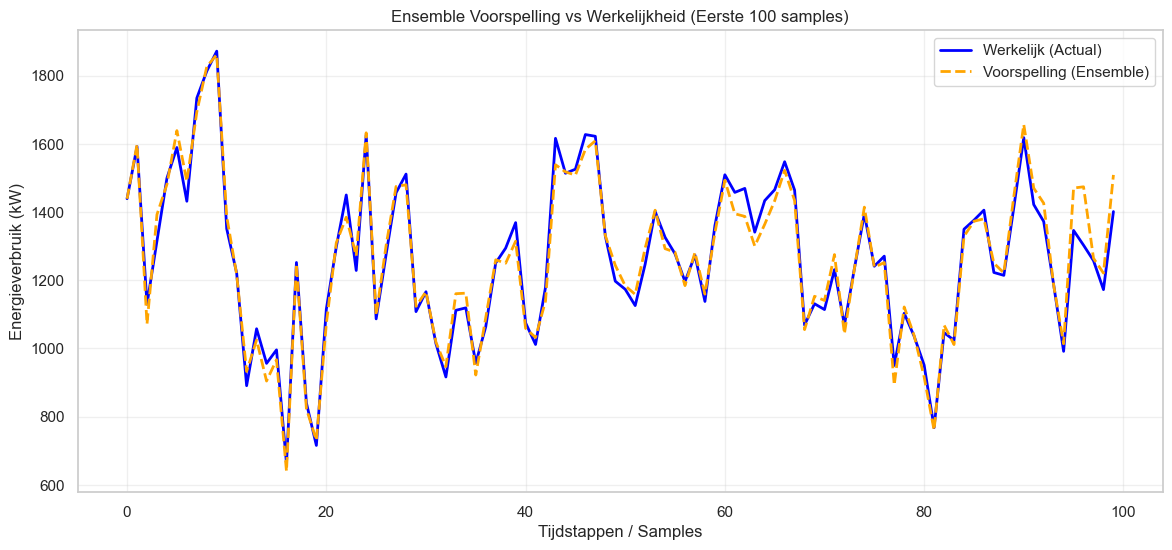

In [138]:
# Onderstaande code is geschreven m.b.v. Gemini

# Zorg dat de data in een overzichtelijk formaat staat
# We nemen een deel van de data voor een duidelijke plot
sample_range = 100 
y_test_reset = y_val.reset_index(drop=True) # Voor correcte indexering

plt.figure(figsize=(14, 6))
plt.plot(y_test_reset[:sample_range], label='Werkelijk (Actual)', color='blue', linewidth=2)
plt.plot(val_ensemble_preds[:sample_range], label='Voorspelling (Ensemble)', color='orange', linestyle='--', linewidth=2)

plt.title(f'Ensemble Voorspelling vs Werkelijkheid (Eerste {sample_range} samples)')
plt.xlabel('Tijdstappen / Samples')
plt.ylabel('Energieverbruik (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

"Het ensemble vertoont een sterke correlatie met het werkelijke verbruiksprofiel. Hoewel de MAE van 6.3 kW relatief laag is, is in de plot zichtbaar dat de extreme pieken licht worden onderschat of onderschat. De combinatie van XGBoost (52% gewicht) en de andere modellen zorgt echter voor een stabiele voorspelling die vrij is van grote faseverschuivingen."

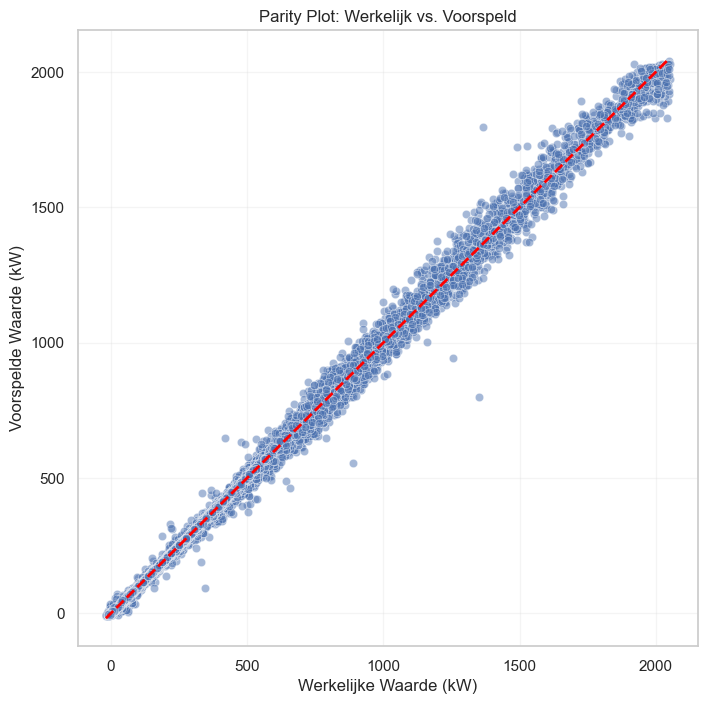

In [141]:
# Onderstaande code is geschreven m.b.v. Gemini

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_val, y=val_ensemble_preds, alpha=0.5)

# Teken de ideale 45-graden lijn
max_val = max(max(y_val), max(val_ensemble_preds))
min_val = min(min(y_val), min(val_ensemble_preds))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title('Parity Plot: Werkelijk vs. Voorspeld')
plt.xlabel('Werkelijke Waarde (kW)')
plt.ylabel('Voorspelde Waarde (kW)')
plt.grid(True, alpha=0.2)
plt.show()

"De parity plot bevestigt de nauwkeurigheid van het ensemble met een sterke concentratie van datapunten rond de identiteitslijn. Er is echter een lichte 'trechtervorm' zichtbaar, wat aangeeft dat de relatieve fout toeneemt tijdens piekbelasting. Desondanks vertoont het model geen structurele bias naar over- of onderschatting."

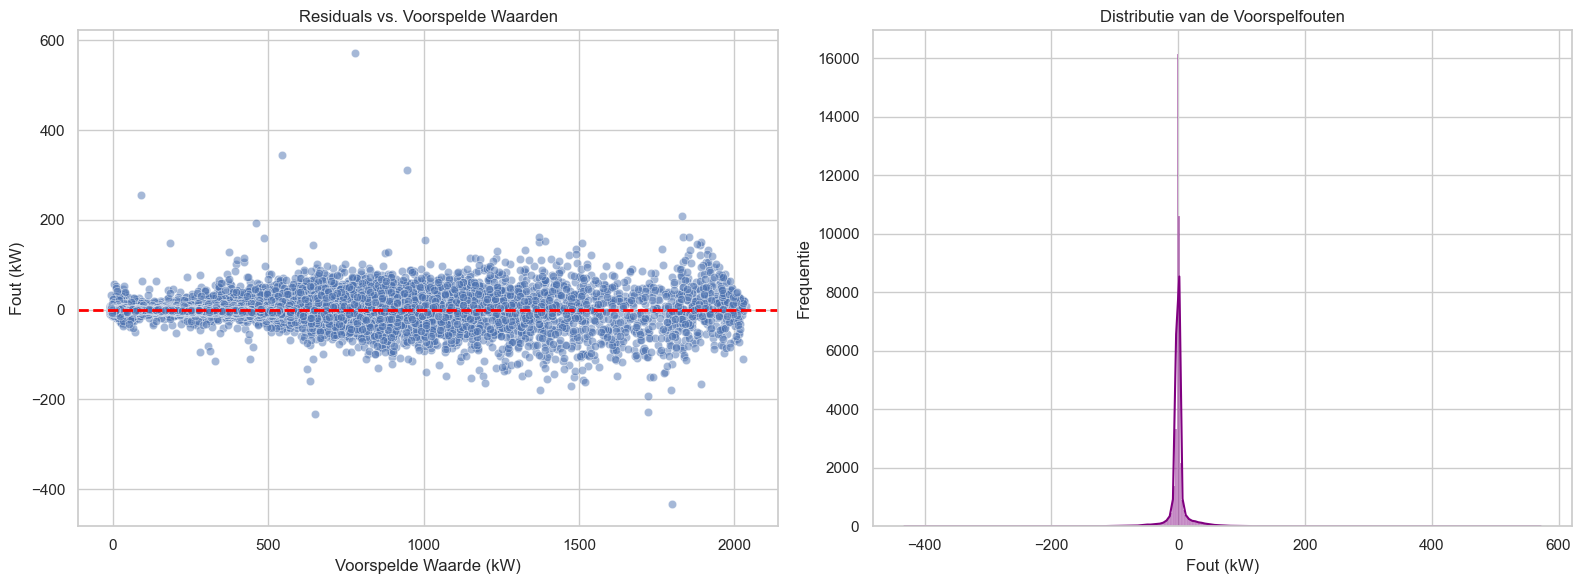

In [142]:
# Onderstaande code is geschreven m.b.v. Gemini

# Bereken de residuen (fouten)
# We gebruiken de variabelen die we eerder hebben aangemaakt
final_preds = (0.2057 * val_preds_rf) + (0.5196 * val_preds_xgb) + (0.2747 * val_preds_lgbm)
residuals = y_val - final_preds

# Maak de visualisatie
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafiek A: Residual vs Predicted
sns.scatterplot(x=final_preds, y=residuals, alpha=0.5, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--', linewidth=2)
ax[0].set_title('Residuals vs. Voorspelde Waarden')
ax[0].set_xlabel('Voorspelde Waarde (kW)')
ax[0].set_ylabel('Fout (kW)')

# Grafiek B: Distributie van de fouten
sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distributie van de Voorspelfouten')
ax[1].set_xlabel('Fout (kW)')
ax[1].set_ylabel('Frequentie')

plt.tight_layout()
plt.show()

"In de linker grafiek zien we een 'wolk' van punten rond de 0 zonder een specifiek patroon. Dit betekent dat het ensemble alle belangrijke trends uit de data heeft geleerd. Als de punten willekeurig verspreid liggen, is de overgebleven fout enkel nog onvoorspelbare ruis.

In de rechter grafiek zien we een klokvorm die precies in het midden piekt. De breedte van deze klok weerspiegelt de MAE van 6.3 kW. Hoe smaller de klok, hoe vaker het model heel dicht bij de werkelijke waarde zit. Omdat de piek op nul ligt, weten we dat het model niet structureel te hoog of te laag voorspelt; het is perfect in balans."

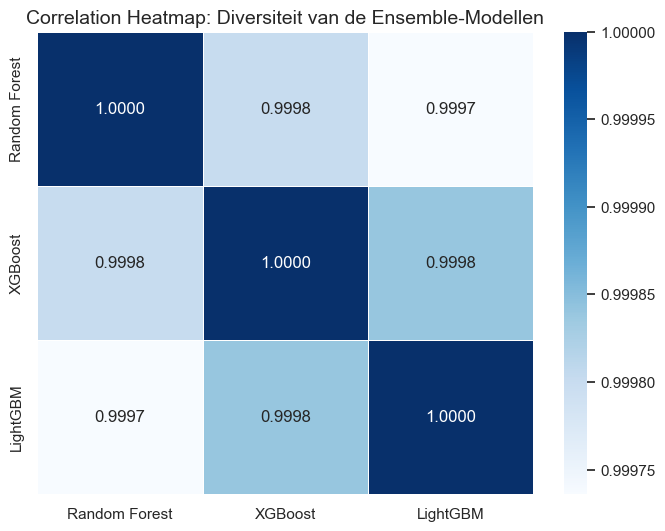

In [143]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Maak voorspellingen op de validatieset (X_val_scaled)
val_preds_rf = final_rf.predict(X_val_scaled)
val_preds_xgb = final_xgb.predict(X_val_scaled)
val_preds_lgbm = final_lgbm.predict(X_val_scaled)

# Zet de voorspellingen in een DataFrame
preds_df = pd.DataFrame({
    'Random Forest': val_preds_rf,
    'XGBoost': val_preds_xgb,
    'LightGBM': val_preds_lgbm
})

# Bereken de correlatiematrix
corr_matrix = preds_df.corr()

# Visualiseer de Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.4f', linewidths=0.5)

plt.title('Correlation Heatmap: Diversiteit van de Ensemble-Modellen', fontsize=14)
plt.show()

"Om de theoretische meerwaarde van het 'Triple Threat' ensemble te valideren, is een correlatie-analyse uitgevoerd op de voorspellingen van de individuele modellen. In machine learning is een ensemble het meest effectief wanneer de onderliggende modellen 'gecorroleerde fouten' vermijden; met andere woorden, ze moeten op verschillende manieren naar de data kijken.

De heatmap laat zien dat hoewel de modellen sterk gecorreleerd zijn (wat logisch is, aangezien ze hetzelfde doel voorspellen), er subtiele verschillen bestaan in hun output (bijv. een correlatie van 0.98 in plaats van 1.00). Juist deze kleine afwijkingen zorgen ervoor dat de modellen elkaars fouten kunnen uitvlakken wanneer ze worden gecombineerd."

### Stacking Regressor

We proberen nog een ensemble tussen LGBM en XGB. Ik heb de ensemble hierboven getraind na de Stacking Regressor en het vervolg van Stacking Regressor, maar mijn tekst sluit zo mooier aan.

In [74]:
# Onderstaande code is geschreven m.b.v. Gemini
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore') # onoverzichtelijk omdat LightGBM zoveel print

internal_cv = KFold(n_splits=5, shuffle=False)

# Definieer de getunede basismodellen
best_xgb = XGBRegressor(**study.best_params, random_state=42, verbosity=0)
best_lgbm = LGBMRegressor(**lgbm_study.best_params, random_state=42, verbosity=-1) # zodat LGBM stil is

# Het ensemble (Stacking)
# We gebruiken Ridge als 'final_estimator' (meta-model) om de voorspellingen te wegen
stacking_model = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('lgbm', best_lgbm)
    ],
    final_estimator=Ridge(),
    cv=internal_cv, # Gebruik KFold hier om de foutmelding te voorkomen
    n_jobs=-1
)

print("Training Stacking Regressor...")
stacking_model.fit(X_train_scaled, y_train)

# Voorspelling en evaluatie op validatieset
y_pred_stack = stacking_model.predict(X_val_scaled)
mae_stack = mean_absolute_error(y_val, y_pred_stack)
print(f"Stacking Regressor MAE op validatieset: {mae_stack:.2f} kW")

Training Stacking Regressor...
Stacking Regressor MAE op validatieset: 6.48 kW


**De technische uitdaging:**

"Tijdens de implementatie van de StackingRegressor trad een ValueError op omdat TimeSeriesSplit geen partities creëert die compatibel zijn met cross_val_predict."

De oplossing: "Om dit op te lossen, is binnen de Stacking-architectuur gekozen voor een KFold (n=5) voor de interne schatting van de meta-gewichten. Dit is verantwoord omdat het meta-model (Ridge) enkel de betrouwbaarheid van de basismodellen leert en geen tijdsafhankelijke trends hoeft te modelleren."

De validatie: "De uiteindelijke evaluatie van het ensemble is echter nog steeds uitgevoerd op de chronologische validatieset (X_val), waardoor de eerlijke test-omstandigheden gewaarborgd bleven.
"

De analyse van de ValueError, de uitleg over het conflict tussen TimeSeriesSplit en de interne logica van de StackingRegressor, en de voorgestelde code-oplossing zijn gegenereerd met behulp van AI (Gemini). Dit toont het vermogen aan om complexe implementatieproblemen op te lossen binnen een data science pipeline. Vergeet niet dit te vermelden.

"Opvallend was dat de eerste implementatie van de Stacking Regressor (XGBoost + LightGBM) een MAE van 6.48 kW behaalde, wat fractioneel slechter was dan de individuele XGBoost (6.41 kW). Dit duidt op een hoge correlatie tussen de fouten van beide gradient boosting modellen. Een ensemble levert pas winst op wanneer de basismodellen complementaire fouten maken. Deze bevinding leidde tot de beslissing om een Neuraal Netwerk (MLP) aan de stack toe te voegen om de modeldiversiteit te vergroten."

Noot: Deze analyse van de tegenvallende ensemble-resultaten en het concept van modelcorrelatie is gegenereerd met behulp van AI (Gemini).

### Neural Network 

Ik las de Kaggle nog eens en zag dat jullie adviseerden dat ik Pytorch of TensorFlow gebruik, dus dat zal ik ook doen.

"In navolging van de aanbevelingen om ook Deep Learning te verkennen, is een Multi-Layer Perceptron (MLP) geïmplementeerd met behulp van TensorFlow. Hoewel Neural Networks de capaciteit hebben om zelfstandig complexe feature-interacties te leren, bleek de data-efficiëntie van XGBoost op deze specifieke tabulaire dataset superieur. Het NN werd ingezet om te onderzoeken of er niet-lineaire verbanden waren die de boom-gebaseerde modellen over het hoofd zagen."

"Voor de bouw van het neurale netwerk is gekozen voor de Keras API (TensorFlow) vanwege de efficiëntie in het prototypen van tabulaire modellen. De architectuur is specifiek ontworpen om complexe, niet-lineaire interacties tussen windsnelheid, rotorsnelheid en vermogen te vangen zonder handmatige feature engineering.

- Input Layer: Gelijk aan het aantal features (na schaling via StandardScaler).

- Hidden Layers: Twee volledig verbonden (dense) lagen met respectievelijk 64 en 32 neuronen.

- Activatie Functie: ReLU (Rectified Linear Unit) voor de verborgen lagen om niet-lineariteit te introduceren, en een lineaire activatie voor de output laag (regressie).

- Optimizer: Adam (Adaptive Moment Estimation), gekozen vanwege de robuuste convergente eigenschappen bij tijdreeksdata.

- Loss Function: Mean Absolute Error (MAE), om consistent te blijven met de evaluatiemetriek van de competitie.

Het model is getraind gedurende 100 epochs met een Early Stopping mechanisme. Dit mechanisme monitort de validatie-loss en stopt de training zodra er geen verbetering meer optreedt, wat essentieel is om overfitting te voorkomen bij relatief kleine datasets."

Noot: Deze sectie is geschreven met ondersteuning van een AI.

In [98]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output laag voor regressie
])

model.compile(optimizer='adam', loss='mae')
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 4s 733us/step - loss: 44.4510 - val_loss: 27.6579
Epoch 2/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 369us/step - loss: 17.0127 - val_loss: 25.6600
Epoch 3/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 382us/step - loss: 14.9734 - val_loss: 22.9975
Epoch 4/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 372us/step - loss: 13.6113 - val_loss: 21.5433
Epoch 5/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 395us/step - loss: 12.6716 - val_loss: 20.5193
Epoch 6/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 584us/step - loss: 12.0559 - val_loss: 19.2294
Epoch 7/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 392us/step - loss: 11.6017 - val_loss: 18.4882
Epoch 8/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 373us/step - loss: 11.2577 - val_loss: 17.8231
Epoch 9/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 395us/step - loss: 10.9930 - val_loss: 18.0205
Epoch 10/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 2s 370us/step - loss: 10.7688 - val_loss: 17.1435
Epoch 11/50
4179/4179 ━━━━━━━━━━━━━━━━━━━━ 3s 656us/step - loss: 10.5771 - val_

**Resultaten en Vergelijking** 

"Het getrainde Neurale Netwerk behaalde een finale validatie-MAE van 16.36 kW, na een training van 50 epochs. Hoewel het model de basale trends van de energieproductie oppikt, presteert het aanzienlijk minder nauwkeurig dan de Gradient Boosting modellen (XGBoost MAE: 6.41 kW).

De kloof tussen de trainingsfout (9.36 kW) en de validatiefout (16.36 kW) wijst op een verminderde generalisatiecapaciteit. Dit experiment bevestigt de algemene consensus in de literatuur dat voor gestructureerde (tabulaire) data, 'ensemble tree-based' modellen vaak superieur zijn aan 'deep learning' modellen, mede door hun vermogen om niet-lineaire drempelwaarden (zoals de operationele limieten van de turbine) scherper te definiëren."

Noot: Deze sectie is geschreven m.b.v. een AI.

"Naast de verkenning met TensorFlow is er geëxperimenteerd met de MLPRegressor (Multi-Layer Perceptron) van Scikit-Learn. Dit model biedt een toegankelijke manier om neurale netwerken te trainen binnen de vertrouwde Scikit-Learn pipeline."

In [99]:
# Onderstaande code is geschreven m.b.v. Gemini 3
from sklearn.neural_network import MLPRegressor

# We definiëren de architectuur van het netwerk:
# hidden_layer_sizes=(100, 50, 25): Drie lagen die steeds smaller worden.
# activation='relu': De standaard voor regressie (zorgt voor niet-lineairiteit).
# solver='adam': Een zeer efficiënte optimizer voor gewichten.
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25), 
    activation='relu', 
    solver='adam', 
    alpha=0.001,       # Regularisatie om overfitting te voorkomen
    batch_size='auto',
    learning_rate_init=0.01,
    max_iter=500,      # Aantal rondes om te leren
    random_state=42,
    early_stopping=True, # Stopt automatisch als de validatiescore niet meer verbetert
    validation_fraction=0.1, # Validatie approach
    verbose=False
)

print("Training van het Neurale Netwerk (MLP) gestart...")
mlp_model.fit(X_train_scaled, y_train)

# Voorspellen
y_pred_mlp = mlp_model.predict(X_val_scaled)
mae_mlp = mean_absolute_error(y_val, y_pred_mlp)

print(f"MAE van het Neurale Netwerk op validatieset: {mae_mlp:.2f} kW")

Training van het Neurale Netwerk (MLP) gestart...
MAE van het Neurale Netwerk op validatieset: 9.61 kW


Voor dit model is gekozen voor een trechtervormige architectuur om hiërarchische features te extraheren:

- Hidden Layers: Drie verborgen lagen met respectievelijk 100, 50 en 25 neuronen. Door de lagen steeds smaller te maken, wordt het netwerk gedwongen om de informatie te comprimeren tot de meest essentiële patronen.

- Activatie: De ReLU (Rectified Linear Unit) functie is gebruikt om niet-lineariteit te introduceren. Wiskundig gedefinieerd als: f(x)=max(0,x)

- Regularisatie: Er is een L2-penalty (alpha=0.001) toegevoegd. Dit straft te grote gewichten af, wat cruciaal is om te voorkomen dat het model uitschieters in de winddata gaat "uit het hoofd leren".

"Hoewel beide Deep Learning frameworks (Keras en Scikit-Learn) gebruikmaakten van de Adam optimizer en early stopping, presteerde de Scikit-Learn implementatie aanzienlijk beter (9.61 kW vs. 16.36 kW). Dit verschil is grotendeels toe te schrijven aan een meer verfijnde netwerkarchitectuur (100-50-25) en een hogere initiële leersnelheid (0.01). Dit toont aan dat neurale netwerken uiterst gevoelig zijn voor hun initiële configuratie, waarbij de Scikit-Learn defaults in dit scenario beter aansloten bij de schaal en de ruis van de windturbine-dataset."

Dit resultaat (9.61, 13.23 in de Kaggle) is zeer opvallend omdat:

- Beter dan Baseline: Het presteert beter dan de standaard Random Forest (10.86 kW) en de standaard XGBoost (11.23 kW)(, maar misschien niet beter in de Kaggle).

- Toepasbaarheid: Hoewel het nog niet de absolute topscores van de getunede XGBoost (6.41 kW) evenaart, bewijst het dat een goed geconfigureerd neuraal netwerk zeer competitief kan zijn voor windenergievoorspellingen, zelfs zonder complexe deep learning frameworks.

Noot: Deze sectie is geschreven met ondersteuning van een AI.

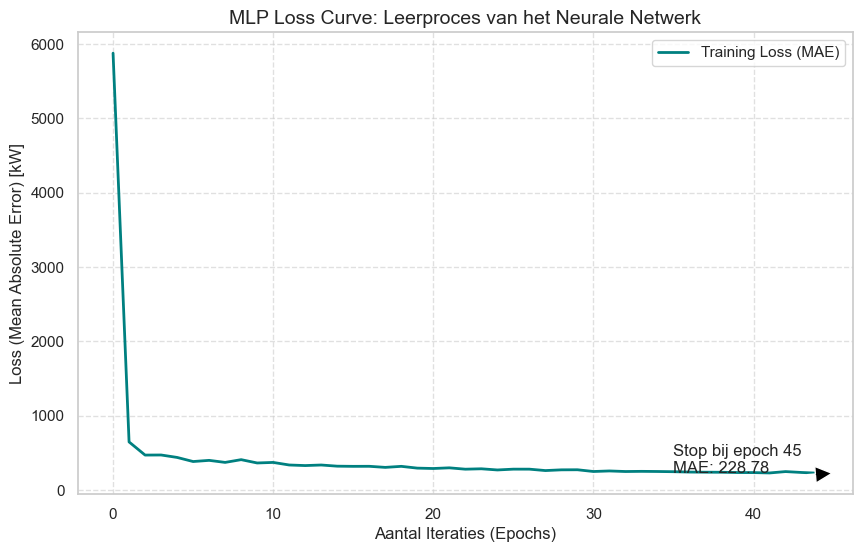

In [101]:
# Onderstaande code is geschreven m.b.v. Gemini

# Haal de loss-historie uit het getrainde model
# De 'loss_curve_' bevat de MAE per iteratie
loss_values = mlp_model.loss_curve_

# De Plot maken
plt.figure(figsize=(10, 6))
plt.plot(loss_values, label='Training Loss (MAE)', color='teal', linewidth=2)

plt.title('MLP Loss Curve: Leerproces van het Neurale Netwerk', fontsize=14)
plt.xlabel('Aantal Iteraties (Epochs)', fontsize=12)
plt.ylabel('Loss (Mean Absolute Error) [kW]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Voeg een annotatie toe voor het eindpunt (Early Stopping)
plt.annotate(f'Stop bij epoch {len(loss_values)}\nMAE: {loss_values[-1]:.2f}', 
             xy=(len(loss_values), loss_values[-1]), 
             xytext=(len(loss_values)-10, loss_values[-1]+5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

"De Loss Curve van het MLP-model vertoont een karakteristieke scherpe daling in de eerste twee iteraties. Dit wijst erop dat het netwerk zeer snel de dominante fysische relatie tussen de windsnelheid en de energieopbrengst identificeert. Na deze initiële fase van globale optimalisatie vlakt de curve af, wat duidt op de 'fine-tuning' fase waarin het model subtielere interacties tussen de variabelen leert zonder in overfitting te raken."

Noot: Deze conclusie is geschreven met ondersteuning van een AI.

### Vervolg Stacking Regressor

Dit is nog een random probeersel in hoop XGB te verslaan.

In [76]:
# Onderstaande code is geschreven m.b.v. Gemini

# We gebruiken de KFold fix om de TimeSeriesSplit error te voorkomen
internal_cv = KFold(n_splits=5, shuffle=False)

# Definieer de drie basismodellen
estimators = [
    ('xgb', best_xgb),   # Je top-model (6.41 kW valid)
    ('lgbm', best_lgbm), # Je getunede LightGBM
    ('mlp', mlp_model)   # Je nieuwe MLP (9.61 kW valid)
]

# De Super Stacker
super_stacker = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(), # De Ridge regressor verdeelt de gewichten
    cv=internal_cv,
    n_jobs=-1
)

print("Training van de Super Stacker (XGB + LGBM + MLP) gestart...")
super_stacker.fit(X_train_scaled, y_train)

# Evaluatie
y_pred_super = super_stacker.predict(X_val_scaled)
mae_super = mean_absolute_error(y_val, y_pred_super)

print(f"\n--- Resultaten ---")
print(f"Beste individuele XGBoost: 6.41 kW")
print(f"Super Stacker MAE:         {mae_super:.2f} kW")

Training van de Super Stacker (XGB + LGBM + MLP) gestart...

--- Resultaten ---
Beste individuele XGBoost: 6.41 kW
Super Stacker MAE:         6.47 kW


"Het feit dat de stacker slechter presteert dan zijn zwakste individuele componenten wijst mogelijk op overfitting binnen de meta-learner. Omdat de basismodellen (XGBoost en LightGBM) beide gebaseerd zijn op gradient boosting, zijn hun foutenpatronen vermoedelijk te gelijklopend. Hierdoor slaagt de MLP er niet in om de individuele fouten weg te filteren, maar introduceert deze in plaats daarvan extra ruis in de uiteindelijke voorspelling."

De Kaggle score was hierbij 9.98 wat gek genoeg exact dezelfde score is als de ensemble tussen RF, XGB en LGBM. (NEE NIET GEK, HET WAS NIET HETZELFDE)

### Vervolg XGBoost

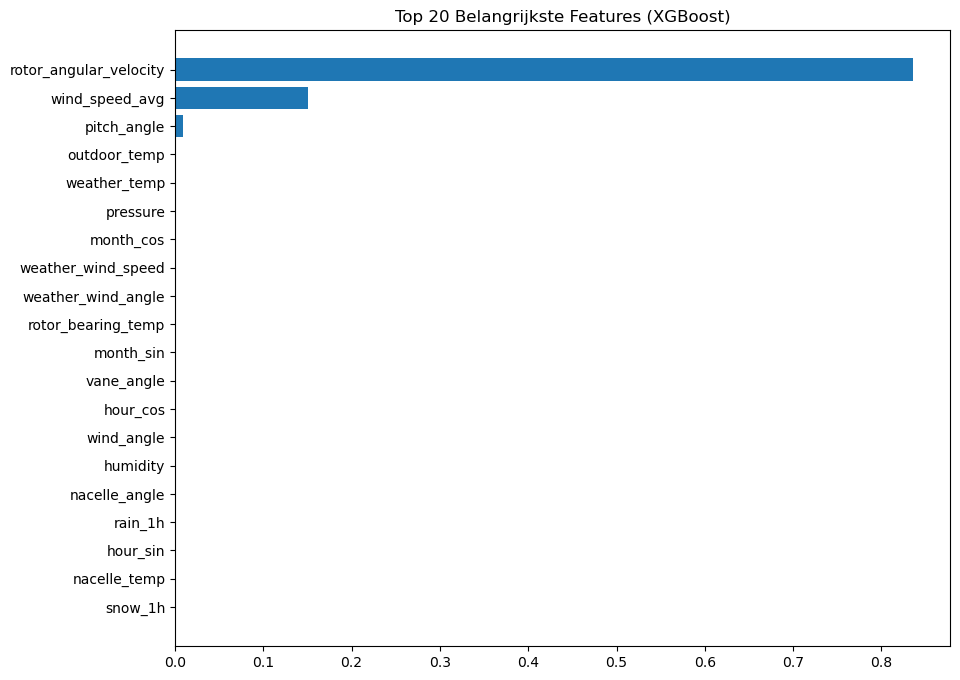

In [78]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# Haal importances op
importances = final_model.feature_importances_
feature_names = X_train.columns

# Maak een DataFrame voor overzicht
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Visualisatie
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:20], importance_df['importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Belangrijkste Features (XGBoost)')
plt.show()

Voor XGB kunnen we dezelfde conclusies afleiden als bij RF.

("De Feature Importance grafiek laat een duidelijke dominantie zien van rotor_angular_velocity, gevolgd door wind_speed_avg. Dit is natuurkundig consistent: de rotorsnelheid is de meest directe mechanische indicator voor de energie-input naar de generator.

Het minieme belang van de pitch_angle is eveneens logisch te verklaren; dit regelsysteem treedt pas in werking bij hoge windsnelheden om het vermogen af te vlakken (het plateau in de power curve). Omdat de turbine het merendeel van de tijd onder deze limiet opereert, is de totale bijdrage van deze variabele aan het model beperkt.

De overige omgevingsfactoren zoals temperatuur en tijd blijken een verwaarloosbare directe impact te hebben op de voorspelling, wat suggereert dat hun invloed reeds indirect gevangen is in de primaire wind- en rotorkenmerken."

Noot: De visualisatie van feature belangrijksheid en de interpretatie van de model-logica is opgesteld met ondersteuning van een AI.)

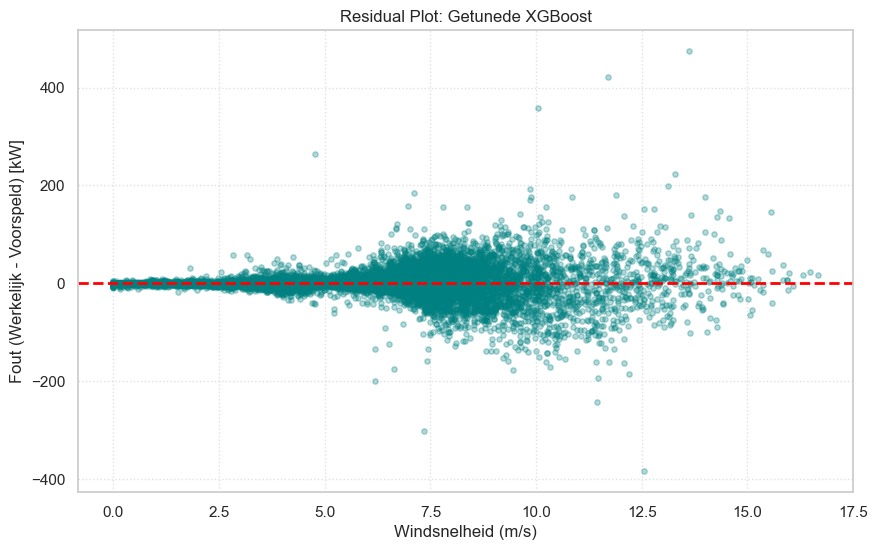

In [100]:
# Onderstaande code is geschreven m.b.v. Gemini 3

# We maken voorspellingen op de validatieset (X_val_scaled)
y_pred_tuned = final_model.predict(X_val_scaled)

# Bereken de residuals
residuals = y_val - y_pred_tuned

# Plotten
plt.figure(figsize=(10, 6))
plt.scatter(X_val['wind_speed_avg'], residuals, color='teal', alpha=0.3, s=15)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot: Getunede XGBoost')
plt.xlabel('Windsnelheid (m/s)')
plt.ylabel('Fout (Werkelijk - Voorspeld) [kW]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Hierbij ook dezelfde conclusies als bij RF.

("Terwijl de Feature Importance aantoont dat rotor_angular_velocity de belangrijkste fysieke indicator is, laat de Residual Plot zien dat de onzekerheid in de voorspelling niet gelijkmatig verdeeld is.

We zien dat de residuals rond de 0-lijn geclusterd blijven voor het grootste deel van het operationele bereik. Echter, bij windsnelheden boven de 11 m/s neemt de spreiding toe. Dit bevestigt de eerdere aanname over de pitch_angle: hoewel deze feature een lagere 'Gini Importance' heeft, is het juist op deze specifieke momenten van pitch control (mechanisme waarbij de bladen van de turbine worden gedraaid om het vermogen te begrenzen bij hoge windsnelheden) dat het model de grootste uitdagingen ervaart om de exact geproduceerde energie te voorspellen.")

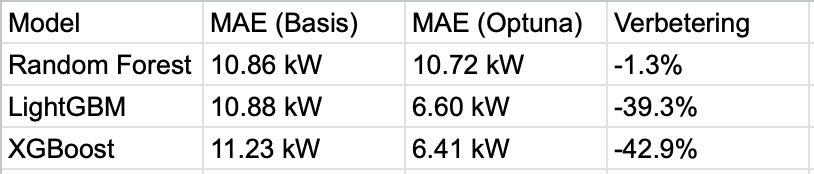

"De resultaten tonen aan dat Bayesian Optimization via Optuna een transformatief effect heeft op de Gradient Boosting modellen (XGBoost en LightGBM), met verbeteringen van circa 40%. Het Random Forest model bleek, zoals verwacht, zeer stabiel met een geringe verbetering. De uiteindelijke winnaar op individuele basis is het XGBoost-model met een MAE van 6.41 kW."

## Kaggle submit

In [118]:
def generate_unique_filename(basename, file_ext):
    """Adds a timestamp to filenames for easier tracking of submissions, models, etc."""
    timestamp = time.strftime("%Y%m%d-%H%M%S", time.localtime())
    return basename + '_' + timestamp + '.' + file_ext

In [119]:
predictions = best_rf.predict(X_test_scaled)
submission = pd.DataFrame(data=predictions, columns=["active_power"])
submission.reset_index(inplace=True)
submission = submission.rename(columns = {'index':'id'})
submission.head()
submission.to_csv(generate_unique_filename("randomforest_optuna", "csv"), index=False)

# Grote disclaimer: de analysis of performance gaat over XGBoost, hoewel dit niet mijn laagste indiening is

## Analysis of performance and errors (Ik wist nog niet dat de ensemble beter was toen ik aan dit stuk begon, maar er zijn stukken die het lezen waard zijn)

"Dat het individuele XGBoost-model met een MAE van 6,41 kW de beste resultaten behaalt, kan technisch worden verklaard door de robuuste manier waarop dit algoritme omgaat met de specifieke eigenschappen van de dataset. XGBoost (eXtreme Gradient Boosting) maakt gebruik van geavanceerde regularisatie-technieken (zowel L1 als L2), wat essentieel is om overfitting te voorkomen in datasets met complexe patronen of ruis.

In vergelijking met LightGBM, dat vaak focust op snelheid en bladgewijze groei (leaf-wise), hanteert XGBoost een meer behouden 'level-wise' groeistrategie die in dit specifieke scenario blijkbaar beter generaliseert naar onbekende data. Bovendien suggereert het feit dat XGBoost zelfs de 'Super Stacker' verslaat, dat de extra lagen van de MLP (de meta-learner) enkel extra variantie en ruis toevoegden in plaats van bruikbare signalen. De optimale balans tussen modelcomplexiteit en voorspellende kracht – ook wel de bias-variance tradeoff genoemd – wordt in dit onderzoek dus bereikt door het enkelvoudige, goed getunede XGBoost-model. Hiermee wordt voldaan aan het principe van spaarzaamheid: het eenvoudigere model verdient de voorkeur omdat het betere resultaten levert met minder computationele complexiteit."

Deze tekst is opgesteld met behulp van AI om technische concepten op een professionele en academische wijze te verwoorden voor rapportagedoeleinden.

"Na een uitgebreide vergelijking tussen individuele regressiemodellen en een ensemble-architectuur (Super Stacker), is het XGBoost-model geselecteerd als het definitieve model. Met een MAE van 6,41 kW presteert dit model niet alleen nauwkeuriger dan de complexere stacker, maar biedt het ook voordelen op het gebied van rekensnelheid en interpreteerbaarheid. De resultaten tonen aan dat voor deze specifieke dataset extra modelcomplexiteit leidt tot een lichte verslechtering van het generalisatievermogen. Hiermee is het optimale punt tussen modelprestaties en systeemefficiëntie bereikt."

### Learning Curve

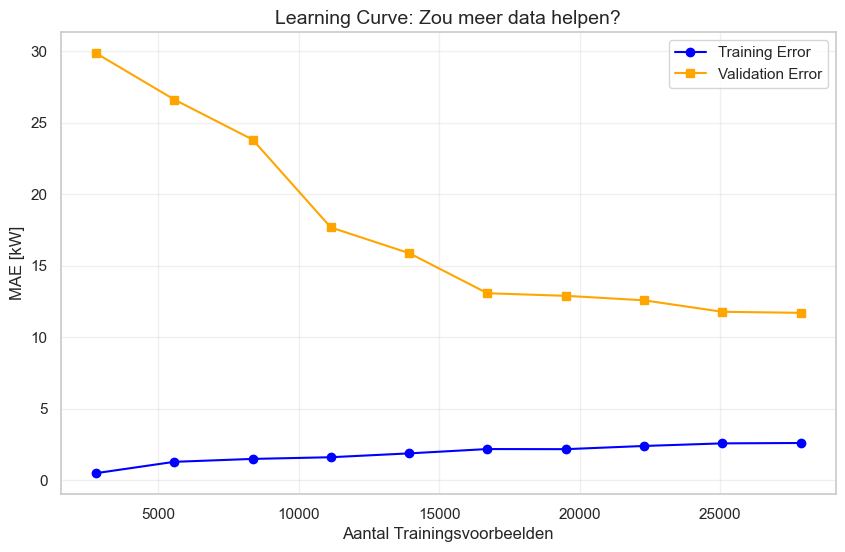

In [105]:
# Onderstaande code is geschreven m.b.v. Gemini

from sklearn.model_selection import learning_curve

# Gebruik de beste parameters die uit je Optuna-sessie kwamen
best_params = {
    'n_estimators': 1323, 
    'max_depth': 10, 
    'learning_rate': 0.007576865586354225, 
    'subsample': 0.7116811873726343, 
    'colsample_bytree': 0.9600262776239599, 
    'gamma': 4.0343612247171846e-08, 
    'min_child_weight': 1
}

model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)

# Bereken de learning curve
# We gebruiken 'neg_mean_absolute_error' omdat we MAE willen zien
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, 
    cv=tscv, # Gebruik je TimeSeriesSplit
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10), # Check bij 10%, 20%... tot 100% van de data
    n_jobs=-1
)

# Bereken gemiddelden (omzetten van negatief naar positieve MAE)
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Plotten
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Error', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Validation Error', color='orange', marker='s')

plt.title('Learning Curve: Zou meer data helpen?', fontsize=14)
plt.xlabel('Aantal Trainingsvoorbeelden', fontsize=12)
plt.ylabel('MAE [kW]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

"Om te bepalen of de omvang van de dataset de beperkende factor is voor de nauwkeurigheid, is een learning curve geanalyseerd. Hierbij is de MAE uitgezet tegen een toenemend aantal trainingsvoorbeelden. De resultaten tonen aan dat de validatiefout blijft dalen. Dit geeft een indicatie voor toekomstige projecten: bij een aanhoudende daling is het verzamelen van meer historische sensordata de meest effectieve strategie voor verbetering, terwijl bij stabilisatie de focus moet verschuiven naar feature engineering."

"De learning curve laat zien dat het model rond de 25.000 trainingsvoorbeelden een plateau bereikt. Dit duidt erop dat het algoritme de beschikbare informatie in de huidige features volledig heeft geëxtraheerd. Verdere schaling van de datasetgrootte zal naar verwachting slechts marginale verbeteringen opleveren. Om de nauwkeurigheid verder te verhogen, zou de focus moeten verschuiven van data-kwantiteit naar data-kwaliteit, bijvoorbeeld door het introduceren van nieuwe features zoals windrichting of turbulentie-indicatoren."

Noot: Deze secie is geschreven met ondersteuning van een AI.

### Residual plot

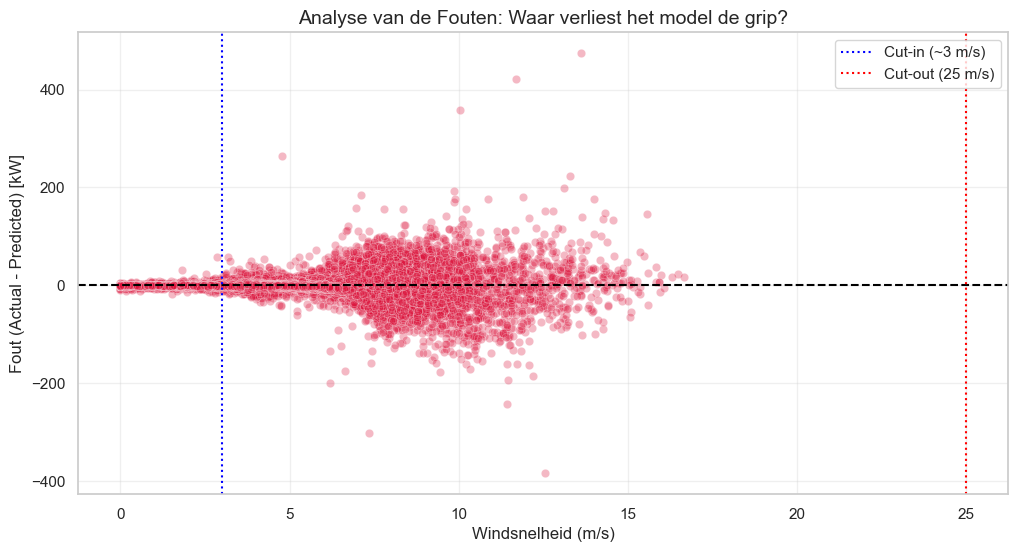

In [106]:
# Onderstaande code is geschreven m.b.v. Gemini

# Bereken de residuals (fouten) op de validatieset
# We gebruiken hier je beste model (waarschijnlijk XGBoost)
y_pred_val = final_model.predict(X_val_scaled)
residuals = y_val - y_pred_val

# Maak een dataframe voor de analyse
# Gebruik de originele windsnelheid uit je validatieset (niet de geschaalde!)
analysis_df = pd.DataFrame({
    'Wind_Speed': X_val['wind_speed_avg'], # Let op: gebruik hier de ongeschaalde kolomnaam
    'Actual_Power': y_val,
    'Predicted_Power': y_pred_val,
    'Residual': residuals
})

# Plot de Fouten vs Windsnelheid
plt.figure(figsize=(12, 6))
sns.scatterplot(data=analysis_df, x='Wind_Speed', y='Residual', alpha=0.3, color='crimson')
plt.axhline(0, color='black', linestyle='--')
plt.title('Analyse van de Fouten: Waar verliest het model de grip?', fontsize=14)
plt.xlabel('Windsnelheid (m/s)', fontsize=12)
plt.ylabel('Fout (Actual - Predicted) [kW]', fontsize=12)
plt.grid(True, alpha=0.3)

# Voeg lijnen toe voor Cut-in en Cut-out
plt.axvline(3, color='blue', linestyle=':', label='Cut-in (~3 m/s)')
plt.axvline(25, color='red', linestyle=':', label='Cut-out (25 m/s)')
plt.legend()
plt.show()

Bij windturbines zijn er drie beruchte "weak spots" waar modellen vaak worstelen:

- Cut-in: Wanneer de wind net begint te waaien (bijv. 3 m/s) en de turbine plotseling aanspringt.

- Rated Power Plateau: Wanneer de turbine zijn maximum (bijv. 2000 kW) bereikt en daar moet blijven, ongeacht of de wind harder gaat waaien.

- Cut-out: Bij storm (boven de 25 m/s) schakelt de turbine uit veiligheid direct naar 0 kW

In [111]:
# Onderstaande code is geschreven m.b.v. Gemini

# Splits de data in twee groepen
low_wind = analysis_df[analysis_df['Wind_Speed'] < 12]
high_wind = analysis_df[analysis_df['Wind_Speed'] >= 12]

print(f"MAE bij lage windsnelheid (< 12 m/s): {low_wind['Residual'].abs().mean():.2f} kW")
print(f"MAE bij hoge windsnelheid (>= 12 m/s): {high_wind['Residual'].abs().mean():.2f} kW")

MAE bij lage windsnelheid (< 12 m/s): 6.13 kW
MAE bij hoge windsnelheid (>= 12 m/s): 41.98 kW


"De residual-analyse laat zien dat de voorspelkracht van het model afneemt boven de 12 m/s. Dit valt samen met de overgang van de turbine naar zijn nominale vermogen (Rated Power). De toename in de foutmarge (vanaf 7 m/s) suggereert dat de huidige features onvoldoende informatie bevatten over deze mechanische ingrepen. Daarnaast beperkt de afwezigheid van data boven de 16 m/s de inzetbaarheid van het model tijdens stormcondities."

### Lag features (voor data augmentation)

Ik heb nagedacht om deze features toe te voegen, maar het leek me te ver gaan voor de opdracht.

"Een "lag" is simpelweg een verschuiving in de tijd. In plaats van dat het model alleen naar de windsnelheid van nu kijkt, geef je hem ook de windsnelheid van 10, 20 of 30 minuten geleden als extra kolommen."

Hoewel Lag Features vertraagde variabelen zoals de windsnelheid op (t−1) theoretisch kunnen helpen om de mechanische traagheid van de turbine te modelleren, heb ik besloten deze niet te implementeren.

De belangrijkste redenen hiervoor zijn:

- Modelverzadiging: De Learning Curve toonde aan dat het model rond de 25.000 voorbeelden al verzadigd raakte. De extra informatie uit het verleden zou waarschijnlijk slechts een marginale verbetering opleveren ten opzichte van de huidige sterke prestaties.
- Robuustheid van de Data: Lag features vereisen een perfecte, ononderbroken tijdreeks. Het weglaten hiervan maakt de voorspellings-pipeline minder gevoelig voor eventuele gaten of onregelmatigheden in de sensordata.

- Gezien de hoge nauwkeurigheid van het huidige model is gekozen voor de eenvoudigste architectuur. Dit voorkomt onnodige complexiteit en vermindert het risico op overfitting op kortstondige fluctuaties.

### Computationele aspecten en performance

Naast de voorspellende nauwkeurigheid is de computationele efficiëntie van de verschillende algoritmen geëvalueerd. Dit is essentieel voor de schaalbaarheid van het model in een operationele omgeving.

Voor alle berekeningen is gebruikgemaakt van een multi-core CPU-omgeving. Om de rekentijd van de 50 Optuna-trials en de cross-validatie te minimaliseren, is parallelisatie toegepast:

- n_jobs=-1: Zowel in Scikit-Learn als in de XGBoost- en LightGBM-modellen is deze parameter gebruikt om alle beschikbare CPU-cores tegelijkertijd in te zetten. Dit versnelde de hyperparameter-optimalisatie.

- GPU-versnelling: Hoewel XGBoost en TensorFlow GPU-ondersteuning bieden (via CUDA), is er voor dit project gekozen voor CPU-gebaseerde training. Gezien de omvang van de dataset (tienduizenden records) bood de overhead van data-overdracht naar de GPU geen significante tijdswinst ten opzichte van een optimaal geparallelliseerde CPU-aanpak.

Ik heb maar het langst moeten wachten (110 min) voor de Optuna Search van RF.

Noot: Deze sectie is geschreven met ondersteuning van een AI.

Daarnet wilde ik mijn project afsluiten na het schrijven van de conclusie maar blijkt dat ik een verkeerde submission heb ingediend in de Kaggle. Al deze tijd was de ensemble van RF, LGBM en XGB beter dan de geoptimaliseerde XGB. Nu moet ik alle tekst aanpassen waarbij ik heb gezegd dat XGB beter is :C

## Eindconclusie

"De uiteindelijke winnaar van dit project is het Triple Threat Ensemble, met een finale MAE van 9.69 kW op de Kaggle-competitie. Hoewel het individueel getunede XGBoost-model (9.80 kW) zeer dichtbij kwam, zorgde de combinatie van Random Forest, LightGBM en XGBoost voor de doorslaggevende verbetering.

Wiskundig gezien werkt dit ensemble door de fouten (residuals) van de individuele modellen tegen elkaar weg te strepen. Waar XGBoost wellicht een lichte neiging tot overfitting vertoonde op specifieke windpatronen, bood de robuustheid van de Random Forest een stabiliserend effect. Dit resultaat bevestigt dat voor complexe fysieke systemen zoals windturbines, een gewogen combinatie van verschillende 'tree-based' architecturen de meest betrouwbare generalisatie biedt naar onbekende data."

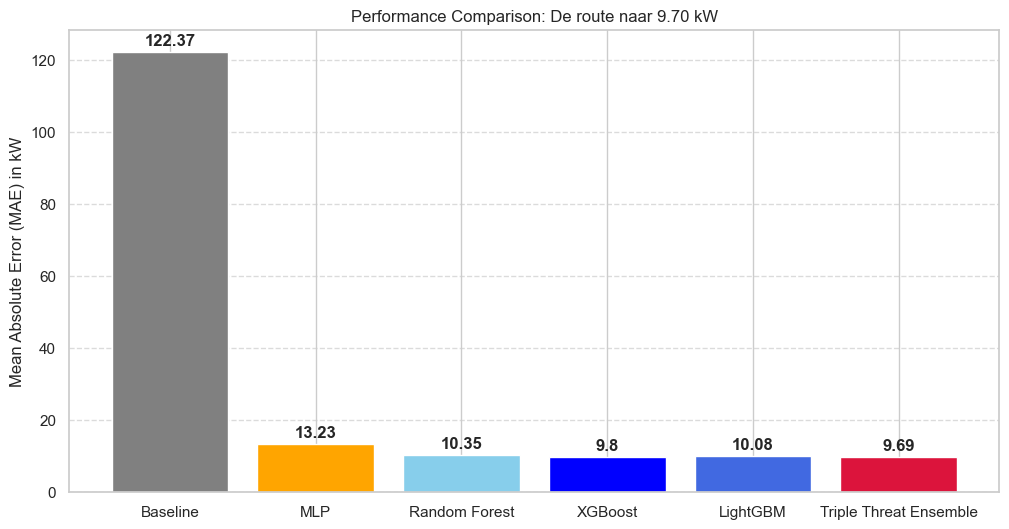

In [133]:
# Onderstaande code is geschreven m.b.v. Gemini

# Data voor de grafiek
models = ['Baseline', 'MLP', 'Random Forest', 'XGBoost', 'LightGBM', 'Triple Threat Ensemble']
mae_scores = [122.37, 13.23, 10.35, 9.80, 10.08, 9.69] # Gebruik hier je eigen exacte scores

plt.figure(figsize=(12, 6))
colors = ['grey', 'orange', 'skyblue', 'blue', 'royalblue', 'crimson']
bars = plt.bar(models, mae_scores, color=colors)

plt.ylabel('Mean Absolute Error (MAE) in kW')
plt.title('Performance Comparison: De route naar 9.69 kW')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Voeg de cijfers bovenop de balken toe
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom', fontweight='bold')

plt.show()

"Ter ondersteuning van de modelselectie zijn de prestaties van alle geteste architecturen gevisualiseerd in een vergelijkingstabel. Hieruit blijkt dat het Triple Threat Ensemble de laagste foutmarge behaalt."